![Multilingual Health Question Answering in Low-Resource African Languages — Challenge by ITU](images/zindi-competetion.png)

# Multilingual Health Q&A — Zindi Challenge

## Abstract

This notebook documents an end-to-end solution for the **Zindi Multilingual Health Q&A** challenge: given a health-related question in one of five African languages, the system returns an expert answer in the **same language**. The final approach is a **retrieval-first, per-subset semantic routing pipeline** that indexes curated question–answer pairs and returns verbatim in-corpus answers ranked by dense multilingual similarity, with sparse TF-IDF blending for low-resource subsets.

Development followed a structured workflow: exploratory data analysis → baseline models → primary semantic system → seven targeted ablations. All runs are logged in `experiment_log.json` and scored locally with **ROUGE-1** and **ROUGE-L** F1 on `Val.csv`.

---

## Leaderboard results

| Metric | Value |
|---|---|
| **Public score** | 0.572643 |
| **Rank** | 199 |
| **Submissions** | 8 |
| **Primary approach** | Semantic routing with expanded train+validation index (E16) |

![Zindi leaderboard — rank 199, score 0.572643](images/zindi-ranking.png)

Local validation (train-only index, no leakage) peaked at **ROUGE-1 F1 = 0.474** (E18). The train+validation knowledge-bank proxy (E16b) reached **ROUGE-1 F1 = 0.493**, consistent with the expanded-index strategy used for Zindi submission.

---

## Languages and data

| Language | Script | Example subset codes |
|---|---|---|
| English | Latin | `Eng_Uga`, `Eng_Gha`, `Eng_Eth`, `Eng_Ken` |
| Akan | Latin (extended) | `Aka_Gha` |
| Luganda | Latin | `Lug_Uga` |
| Swahili | Latin | `Swa_Ken` |
| Amharic | Ge'ez (Ethiopic) | `Amh_Eth` |

The `subset` column encodes both language and country (e.g. `Eng_Uga` = English, Uganda).

---

## Notebook structure

| Section | Topic |
|---|---|
| 1 | Pipeline overview and design principles |
| 2–4 | Environment setup, dependencies, paths |
| 5–6 | Data loading and exploratory analysis |
| 7–8 | Preprocessing and ROUGE evaluation |
| 9 | Experiment tracker |
| 10–12 | Baselines: TF-IDF (E01), zero-shot mT5 (E07), comparison |
| 13–14 | Semantic routing (E16) and ablations (E17–E23) |
| 15 | Test prediction export |
| 16–17 | Results discussion and reproducibility |

**Runtime:** Section 11 (LLM baseline) requires a **T4 GPU**. Sections 13–14 benefit from GPU for embedding encoding but run on CPU.

---

## Evaluation protocol

Two evaluation modes are reported throughout:

| Mode | Index | Purpose |
|---|---|---|
| **Honest (E16a)** | `Train.csv` only | Measures generalisation without validation leakage |
| **Leaderboard proxy (E16b)** | `Train + Val` | Approximates the expanded knowledge bank permitted at submission time; `exclude_id` prevents self-match on validation queries |

## 1 — End-to-end pipeline overview

This notebook runs on **Google Colab**. Data is read from Google Drive; outputs (figures, submissions, experiment log) are written to the working directory.

```mermaid
flowchart LR
    A["Raw CSVs<br/>Train / Val / Test"]
    B["EDA & Insights"]
    C["Preprocessing<br/>clean & language map"]
    D["Baselines<br/>TF-IDF & zero-shot LLM"]
    E["Semantic routing<br/>per-subset retrieval"]
    F["Answer selection<br/>verbatim from corpus"]
    G["Local evaluation<br/>ROUGE on Val"]
    H["Export predictions<br/>CSV submission"]

    A --> B --> C --> D --> E --> F --> G --> H
```

### Design principles

1. **Evidence-driven modelling.** Architectural choices trace to quantitative EDA findings (Section 6.1).
2. **Baseline anchoring.** Sparse and generative baselines define the performance envelope before optimisation.
3. **Retrieval-first architecture.** Expert answers in the training corpus overlap strongly with references; returning in-corpus text outperforms unconstrained generation on this task.
4. **Subset-aware routing.** Language–country subsets receive independent indexes and hybrid blend weights.
5. **Reproducible experimentation.** Fixed random seed, structured logging, and documented evaluation protocols.
6. **Transparent evaluation.** Honest and proxy metrics are reported separately to avoid conflating generalisation with submission strategy.

## 2 — Environment setup

### Google Colab

1. Open this notebook in [Google Colab](https://colab.research.google.com/).
2. Set **Runtime → Change runtime type → T4 GPU** when running Section 11 (LLM baseline).
3. Sections 13–14 (semantic routing) run on CPU; a GPU speeds up embedding encoding.

### Google Drive

Upload the three dataset CSV files to `My Drive/zindi-challenge/`:

- `Train.csv`, `Val.csv`, `Test.csv`

The setup cell below mounts Drive and verifies that all dataset files are present before proceeding.

In [1]:
import os
from pathlib import Path

from google.colab import drive

DRIVE_DATA_FOLDER = 'zindi-challenge'
REQUIRED_FILES = ['Train.csv', 'Test.csv', 'Val.csv']
WORK_DIR = Path('/content/multilingual-health-qa')


def require_dataset_files(data_dir: Path) -> Path:
    data_dir = Path(data_dir)
    missing = [name for name in REQUIRED_FILES if not (data_dir / name).exists()]
    if missing:
        raise FileNotFoundError(
            f'Missing in {data_dir}: {missing}\n'
            f'Create My Drive/{DRIVE_DATA_FOLDER}/ and upload the three dataset CSV files.'
        )
    return data_dir


import torch

if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('WARNING: No GPU detected. Use Runtime -> Change runtime type -> T4 GPU before fine-tuning.')

WORK_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(WORK_DIR)

drive.mount('/content/drive')
DATA_DIR = Path('/content/drive/MyDrive') / DRIVE_DATA_FOLDER
require_dataset_files(DATA_DIR)

print(f'Data folder : {DATA_DIR}')
print(f'Work folder : {WORK_DIR.resolve()}')


GPU: Tesla T4
Mounted at /content/drive
Data folder : /content/drive/MyDrive/zindi-challenge
Work folder : /content/multilingual-health-qa


## 3 — Install dependencies

This cell installs Python packages required for data analysis, evaluation, and modelling.

| Package group | Purpose |
|---|---|
| `pandas`, `matplotlib`, `seaborn` | Data handling and visualisation |
| `scikit-learn` | TF-IDF and nearest-neighbour retrieval |
| `rouge-score` | Local ROUGE evaluation |
| `sentence-transformers` | Semantic routing (Section 13) |
| `transformers`, `datasets`, `accelerate` | Optional zero-shot LLM baselines (Section 11) |
| `sentencepiece`, `protobuf` | Tokenisation for mT5 |

NumPy and PyTorch are not reinstalled on Colab. If installation fails, restart the runtime and run this cell again.


In [2]:
# Install required packages (Google Colab)
import sys

# Do not pin numpy — Colab pre-installed packages (jax, opencv, etc.) require numpy>=2.
!{sys.executable} -m pip install -q scikit-learn pandas rouge-score matplotlib seaborn

# Semantic retrieval — multilingual sentence encoder.
!{sys.executable} -m pip install -q sentence-transformers tqdm

# Optional: zero-shot LLM baseline (Section 11). Skip if you only run retrieval.
!{sys.executable} -m pip install -q 'transformers>=4.44,<4.52' datasets sentencepiece protobuf accelerate safetensors peft bitsandbytes

import importlib.util
for pkg in ('google.protobuf', 'sentencepiece'):
    if importlib.util.find_spec(pkg) is None:
        print(f'Optional package {pkg} not installed — Section 11 LLM cells will not run.')

try:
    import transformers.utils.import_utils as _tf_import_utils
    _tf_import_utils._sentencepiece_available = _tf_import_utils._is_package_available('sentencepiece')
except ImportError:
    pass

print('Dependencies installed.')


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 73.6 MB/s eta 0:00:00
Dependencies installed.


In [3]:
import re
import json
import random
import warnings
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_columns', None)

print('Imports complete')

Imports complete


## 4 — Paths and configuration

| Variable | Location | Contents |
|---|---|---|
| `DATA_DIR` | `My Drive/zindi-challenge/` | Dataset CSV files (read from Drive) |
| `WORK_DIR` | `/content/multilingual-health-qa/` | Generated outputs |
| `FIGURES_DIR` | `WORK_DIR/figures/` | EDA and experiment plots |
| `EXPERIMENT_LOG_PATH` | `WORK_DIR/experiment_log.json` | Experiment tracker log |
| `OUTPUT_SEMANTIC` | `WORK_DIR/submission_semantic_routing.csv` | **Primary Zindi submission (E16)** |
| `OUTPUT_TFIDF` | `WORK_DIR/submission_tfidf_baseline.csv` | TF-IDF baseline export |
| `OUTPUT_LLM` | `WORK_DIR/submission_llm_baseline.csv` | LLM baseline export |
| `SEMANTIC_SUBMISSION_PATHS` | `WORK_DIR/submission_e17_*.csv` … `e23` | Semantic ablation exports |

All three input files must show **OK** before proceeding. If any file is **MISSING**, check the Drive folder path in Section 2.

In [4]:
TRAIN_PATH      = DATA_DIR / 'Train.csv'
TEST_PATH       = DATA_DIR / 'Test.csv'
VAL_PATH        = DATA_DIR / 'Val.csv'

OUTPUT_TFIDF     = WORK_DIR / 'submission_tfidf_baseline.csv'
OUTPUT_LLM       = WORK_DIR / 'submission_llm_baseline.csv'
OUTPUT_SEMANTIC  = WORK_DIR / 'submission_semantic_routing.csv'

SEMANTIC_SUBMISSION_PATHS = {
    'E17': WORK_DIR / 'submission_e17_hybrid_tuning.csv',
    'E18': WORK_DIR / 'submission_e18_char_tfidf.csv',
    'E19': WORK_DIR / 'submission_e19_e5_encoder.csv',
    'E20': WORK_DIR / 'submission_e20_score_norm.csv',
    'E21': WORK_DIR / 'submission_e21_conflict_aware.csv',
    'E22': WORK_DIR / 'submission_e22_sim_threshold.csv',
    'E23': WORK_DIR / 'submission_e23_cross_subset.csv',
}

EXPERIMENT_LOG_PATH = WORK_DIR / 'experiment_log.json'
FIGURES_DIR         = WORK_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
EMBEDDING_CACHE_DIR = WORK_DIR / 'embedding_cache'
EMBEDDING_CACHE_DIR.mkdir(parents=True, exist_ok=True)

for path in [TRAIN_PATH, TEST_PATH, VAL_PATH]:
    status = 'OK' if path.exists() else 'MISSING'
    print(f'{status}: {path}')

print(f'Outputs and figures -> {WORK_DIR.resolve()}')
print(f'Semantic ablation submissions: {len(SEMANTIC_SUBMISSION_PATHS)} files (E17–E23)')


OK: /content/drive/MyDrive/zindi-challenge/Train.csv
OK: /content/drive/MyDrive/zindi-challenge/Test.csv
OK: /content/drive/MyDrive/zindi-challenge/Val.csv
Outputs and figures -> /content/multilingual-health-qa
Semantic ablation submissions: 7 files (E17–E23)


## 5 — Data loading

The challenge provides three CSV files:

| File | Role | Key columns |
|---|---|---|
| `Train.csv` | Knowledge bank for retrieval | `input`, `output`, `subset`, `language` |
| `Val.csv` | Local evaluation (ROUGE) | Same as train |
| `Test.csv` | Held-out questions for submission | `ID`, `input`, `subset`, `language` |

The cell below loads all splits, reports row counts, and displays sample rows for schema verification.

In [5]:
train             = pd.read_csv(TRAIN_PATH)
test              = pd.read_csv(TEST_PATH)
val               = pd.read_csv(VAL_PATH)

print(f'Train shape : {train.shape}')
print(f'Val shape   : {val.shape}')
print(f'Test shape  : {test.shape}')
print()
print('Train columns:', train.columns.tolist())
print('Test columns :', test.columns.tolist())
print('Val columns  :', val.columns.tolist())

display(train.head(3))
display(test.head(3))

Train shape : (29815, 4)
Val shape   : (6686, 4)
Test shape  : (2618, 3)

Train columns: ['ID', 'input', 'output', 'subset']
Test columns : ['ID', 'input', 'subset']
Val columns  : ['ID', 'input', 'output', 'subset']


,ID,input,output,subset
0,ID_TR_Aka_Gha_A3B1799D,Ɔkwan bɛn so na mmabunbɛtumi aboa wɔn mfɛfoɔ a nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ? Yei bi ne sɛnea wɔbɛkyekye w...,Mmabun betumi aboa atipɛnfo a ebia nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ so denam: Nkate fam mmoa a wɔde bɛma na w...,Aka_Gha
1,ID_TR_Aka_Gha_1C80317F,"Edinnsiananmu bɛn na nnipa a ɛsono wɔn bɔbeasu taa de di dwuma, na yɛbɛyɛ dɛn ahwɛ ahu sɛ yɛde redi dwuma yiye?","Wɔ Ghana mu no, amanmmra no gye binary gender nkutoo tom a she/he edinnsiananmu nkutoo na ɛka ho",Aka_Gha
2,ID_TR_Aka_Gha_06671AD1,Ɔkwan bɛn so na ɔbarima ne ɔbea nna a wɔtwe wɔn ho fi ho anaa nna mu adwumadi a wɔtwentwɛn so no boa ma asiane so tew?,"Sɛ wɔtwe wɔn ho fi nna mu anaasɛ wɔtwentwɛn wɔn nan ase a, ɛboa ma asiane nso tew denam asiane a ɛwɔ STI ne HIV a ɛb...",Aka_Gha


,ID,input,subset
0,ID_TS_Aka_Gha_A3B1799D,"Fa nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛma, adwumayɛbea ahorow, ne akuo ahorow a wɔreyɛ adwuma de asiw GBV ano ma.",Aka_Gha
1,ID_TS_Aka_Gha_1C80317F,Dɛn ne nea ebetumi afi hokwan a mmabun wɔ sɛ wonya nipadua mu ahofadi wɔ nna ne awoɔ akwahosan ho nhyehyɛe mu a wobu...,Aka_Gha
2,ID_TS_Aka_Gha_06671AD1,Akwan bɛn na mmabun bɛtumi afa so ehunu nsusuanso a ɛtumi aba ɛfa nnipa a wɔbɛgyina ho kɛkɛ 'bystander' wɔ bere a as...,Aka_Gha


## 6 — Exploratory data analysis (EDA)

Exploratory analysis is completed **before any modelling**. The objective is to characterise language distribution, text length patterns, script diversity, and data-quality issues that constrain pipeline design.

### Generated figures

Fifteen charts are saved to `FIGURES_DIR`:

| Chart group | Files | Purpose |
|---|---|---|
| Overview | `eda_overview.png` | Subset counts, language balance, length scatter |
| Split comparison | `eda_split_sizes.png`, `eda_language_share_splits.png` | Train/Val/Test proportions |
| Geography & script | `eda_country_distribution.png`, `eda_script_pie.png`, `eda_language_country_heatmap.png` | Country and script breakdown |
| Length analysis | `eda_question_length_kde.png`, `eda_answer_length_kde.png`, `eda_qa_ratio_boxplot.png`, `eda_question_length_by_subset.png`, `eda_answer_length_cdf.png` | Token limits and truncation |
| Data quality | `eda_duplicate_questions.png`, `eda_duplicate_qa_taxonomy.png`, `eda_exact_qa_duplicate_distribution.png`, `eda_test_subset_distribution.png` | Duplicates and conflicting labels |

Section 6.1 maps each finding to a concrete modelling decision.

In [6]:
ID_COL            = 'ID'
TEST_ID_COL       = 'ID'
QUESTION_COL      = 'input'
TEST_QUESTION_COL = 'input'
ANSWER_COL        = 'output'
LANG_COL          = 'subset'
TEST_LANG_COL     = 'subset'

SUBSET_TO_LANGUAGE = {
    'Eng': 'English',
    'Aka': 'Akan',
    'Lug': 'Luganda',
    'Swa': 'Swahili',
    'Amh': 'Amharic',
}

SUBSET_TO_SCRIPT = {
    'Eng': 'Latin',
    'Aka': 'Latin',
    'Lug': 'Latin',
    'Swa': 'Latin',
    'Amh': "Ge'ez (Ethiopic)",
}

def subset_to_language_name(subset_code: str) -> str:
    if not subset_code or not isinstance(subset_code, str):
        return 'English'
    return SUBSET_TO_LANGUAGE.get(subset_code.split('_')[0], subset_code)

def subset_to_script(subset_code: str) -> str:
    if not subset_code or not isinstance(subset_code, str):
        return 'Unknown'
    return SUBSET_TO_SCRIPT.get(subset_code.split('_')[0], 'Unknown')

for df in [train, val]:
    df['q_len'] = df[QUESTION_COL].astype(str).str.len()
    df['a_len'] = df[ANSWER_COL].astype(str).str.len()
    df['language'] = df[LANG_COL].map(subset_to_language_name)
    df['script'] = df[LANG_COL].map(subset_to_script)

test['q_len'] = test[TEST_QUESTION_COL].astype(str).str.len()
test['language'] = test[TEST_LANG_COL].map(subset_to_language_name)

print('Language distribution - training set:')
display(train['subset'].value_counts().to_frame('count'))

print('\nPer-language aggregation (train):')
lang_summary = (
    train.groupby('language')
    .agg(
        n=('ID', 'count'),
        q_len_mean=('q_len', 'mean'),
        a_len_mean=('a_len', 'mean'),
        a_len_p95=('a_len', lambda s: s.quantile(0.95)),
    )
    .round(1)
    .sort_values('n', ascending=False)
)
display(lang_summary)

_dup_probe = pd.DataFrame({
    '_q': train[QUESTION_COL].astype(str).str.strip(),
    '_a': train[ANSWER_COL].astype(str).str.strip(),
})
_q_meta = _dup_probe.groupby('_q').agg(n_rows=('_q', 'size'), n_answers=('_a', 'nunique'))

stats = {
    'train_rows': len(train),
    'val_rows': len(val),
    'test_rows': len(test),
    'unique_train_questions': train[QUESTION_COL].nunique(),
    'duplicate_train_questions': int(train[QUESTION_COL].duplicated().sum()),
    'repeat_question_same_answer': int(((_q_meta['n_rows'] > 1) & (_q_meta['n_answers'] == 1)).sum()),
    'questions_with_conflicting_answers': int((_q_meta['n_answers'] > 1).sum()),
    'exact_qa_duplicate_groups': int(_dup_probe.groupby(['_q', '_a']).size().gt(1).sum()),
    'train_val_overlap': len(set(train[QUESTION_COL]) & set(val[QUESTION_COL])),
    'q_len_p95_train': float(train['q_len'].quantile(0.95)),
    'a_len_p95_train': float(train['a_len'].quantile(0.95)),
    'qa_ratio_mean': float((train['a_len'] / train['q_len'].clip(lower=1)).mean()),
}
print('\nKey EDA statistics:')
for k, v in stats.items():
    print(f'  {k}: {v}')

Language distribution - training set:


,count
subset,
Eng_Uga,7624
Aka_Gha,4455
Eng_Gha,4443
Eng_Eth,3915
Lug_Uga,3383
Eng_Ken,2080
Swa_Ken,2070
Amh_Eth,1845



Per-language aggregation (train):


,n,q_len_mean,a_len_mean,a_len_p95
language,,,,
English,18062,84.4,484.7,1205.0
Akan,4455,144.2,545.1,1080.3
Luganda,3383,82.9,648.9,1396.0
Swahili,2070,70.4,541.8,1210.0
Amharic,1845,47.9,105.1,176.0



Key EDA statistics:
  train_rows: 29815
  val_rows: 6686
  test_rows: 2618
  unique_train_questions: 28346
  duplicate_train_questions: 1469
  repeat_question_same_answer: 284
  questions_with_conflicting_answers: 1184
  exact_qa_duplicate_groups: 284
  train_val_overlap: 0
  q_len_p95_train: 195.0
  a_len_p95_train: 1209.0
  qa_ratio_mean: 6.704487501361247


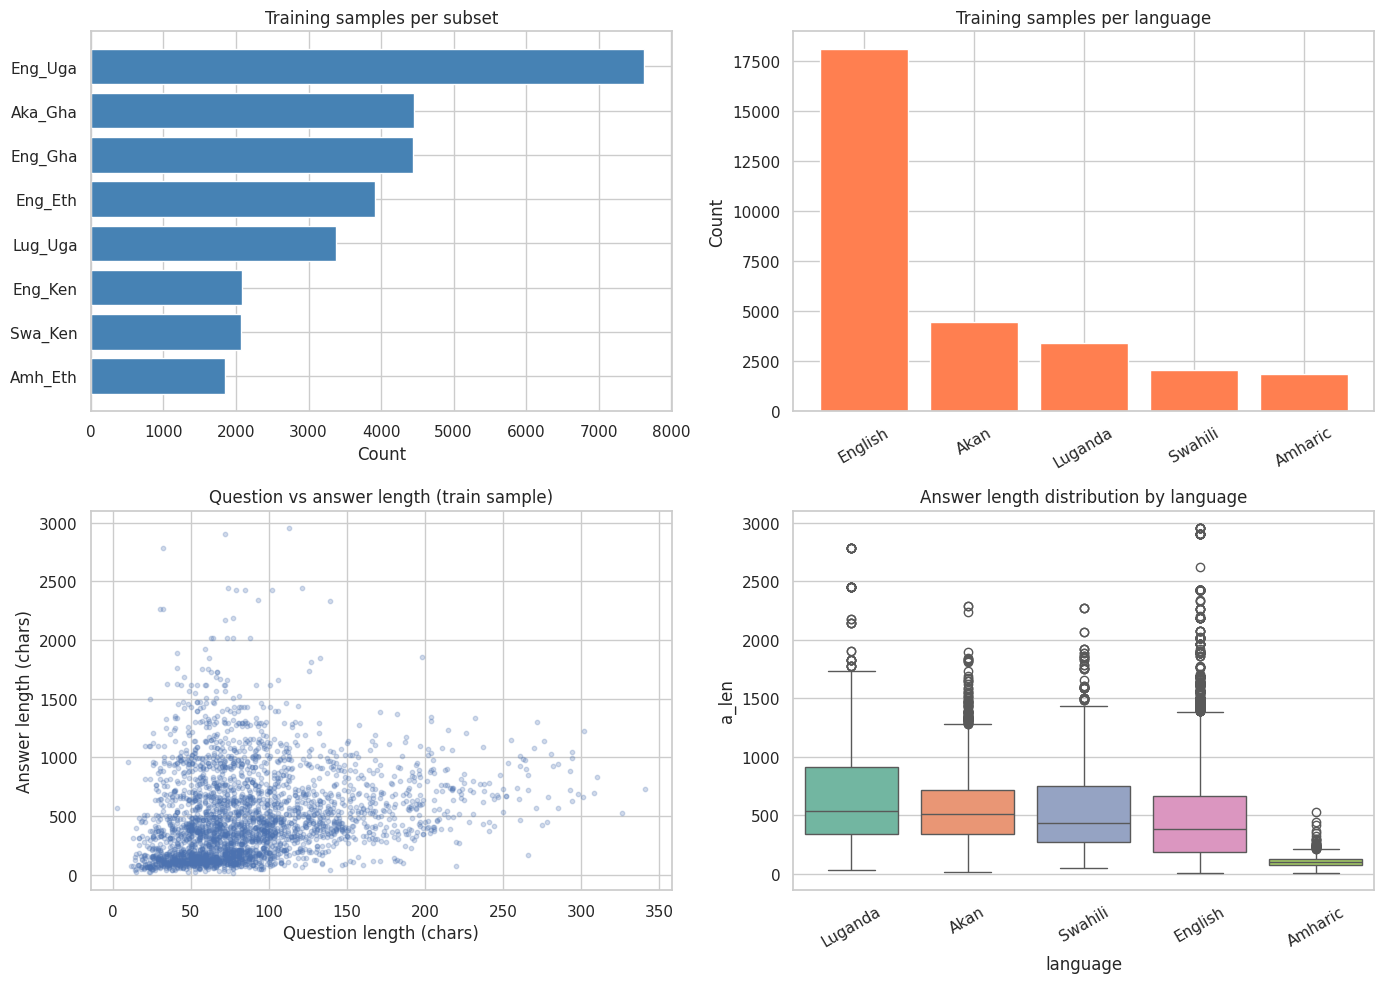

Saved: /content/multilingual-health-qa/figures/eda_overview.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

subset_counts = train['subset'].value_counts()
axes[0, 0].barh(subset_counts.index[::-1], subset_counts.values[::-1], color='steelblue')
axes[0, 0].set_title('Training samples per subset')
axes[0, 0].set_xlabel('Count')

lang_counts = train['language'].value_counts()
axes[0, 1].bar(lang_counts.index, lang_counts.values, color='coral')
axes[0, 1].set_title('Training samples per language')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=30)

sample_idx = train.sample(min(3000, len(train)), random_state=SEED)
axes[1, 0].scatter(sample_idx['q_len'], sample_idx['a_len'], alpha=0.25, s=10)
axes[1, 0].set_xlabel('Question length (chars)')
axes[1, 0].set_ylabel('Answer length (chars)')
axes[1, 0].set_title('Question vs answer length (train sample)')

order = train.groupby('language')['a_len'].median().sort_values(ascending=False).index
sns.boxplot(data=train, x='language', y='a_len', order=order, ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Answer length distribution by language')
axes[1, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
eda_fig_path = FIGURES_DIR / 'eda_overview.png'
plt.savefig(eda_fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {eda_fig_path}')


Saved: /content/multilingual-health-qa/figures/eda_split_sizes.png


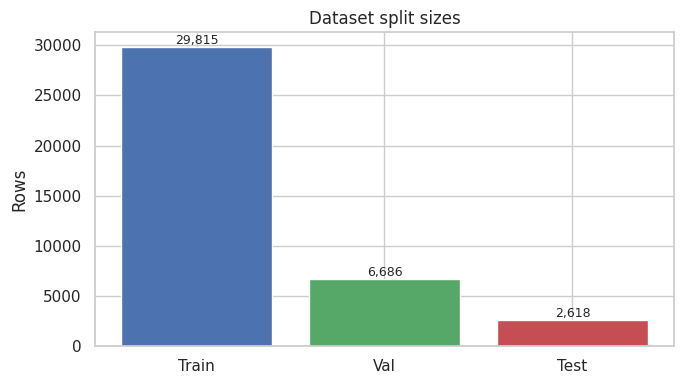

Saved: /content/multilingual-health-qa/figures/eda_language_share_splits.png


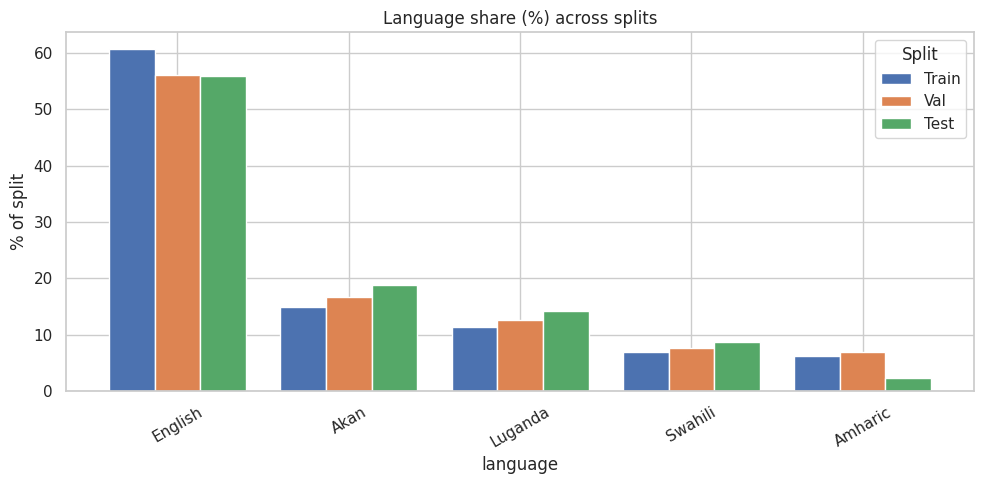

Saved: /content/multilingual-health-qa/figures/eda_country_distribution.png


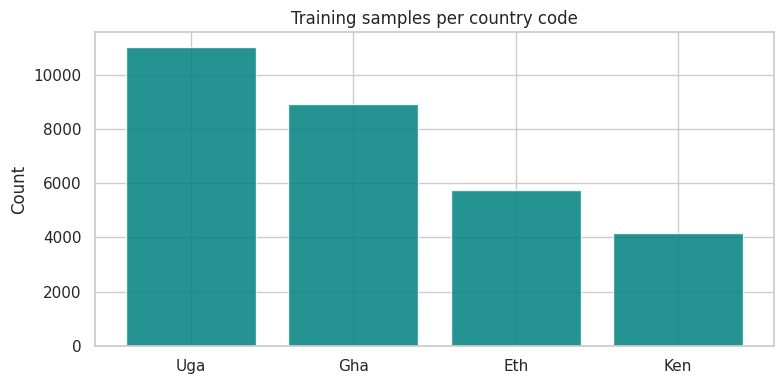

Saved: /content/multilingual-health-qa/figures/eda_script_pie.png


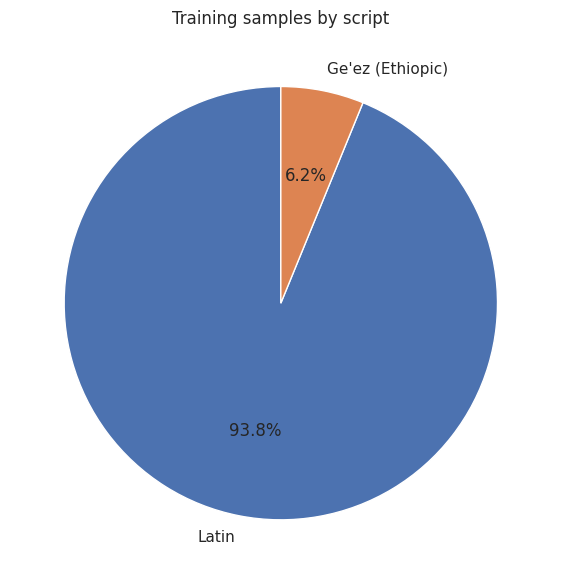

Saved: /content/multilingual-health-qa/figures/eda_question_length_kde.png


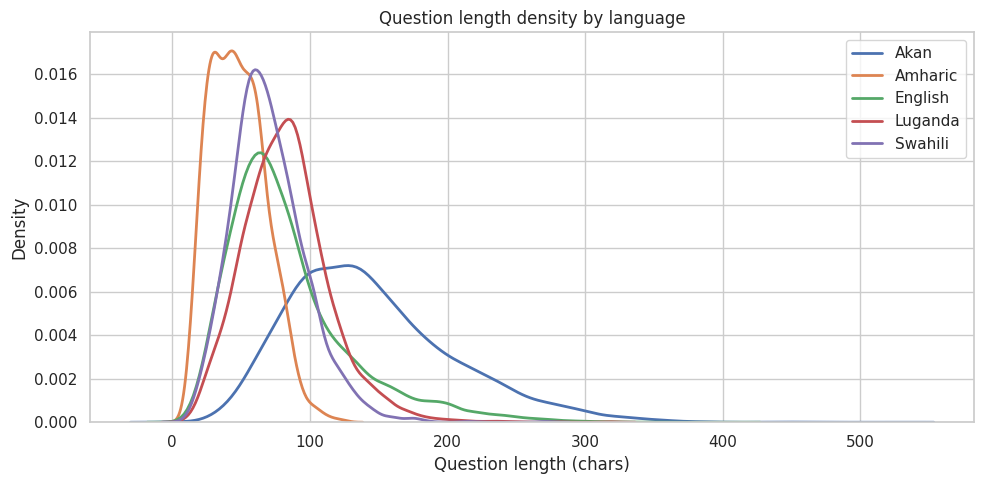

Saved: /content/multilingual-health-qa/figures/eda_answer_length_kde.png


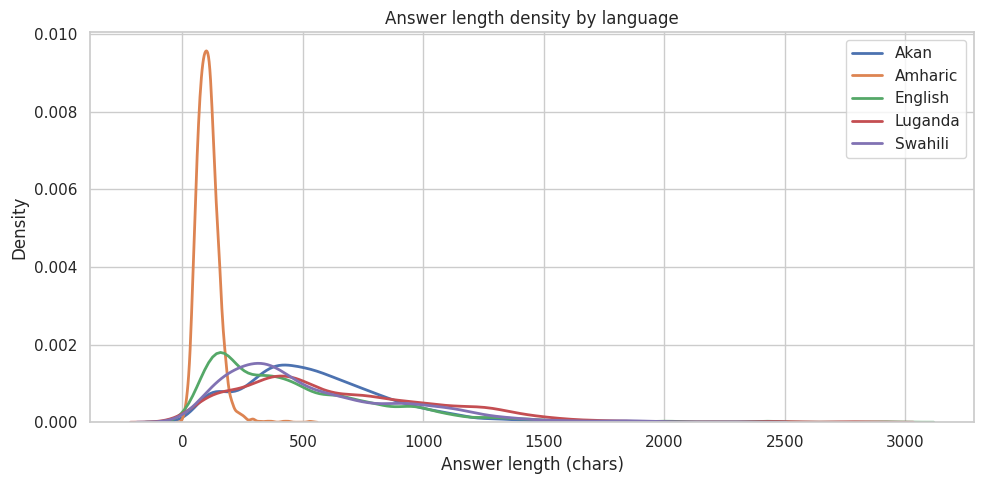

Saved: /content/multilingual-health-qa/figures/eda_qa_ratio_boxplot.png


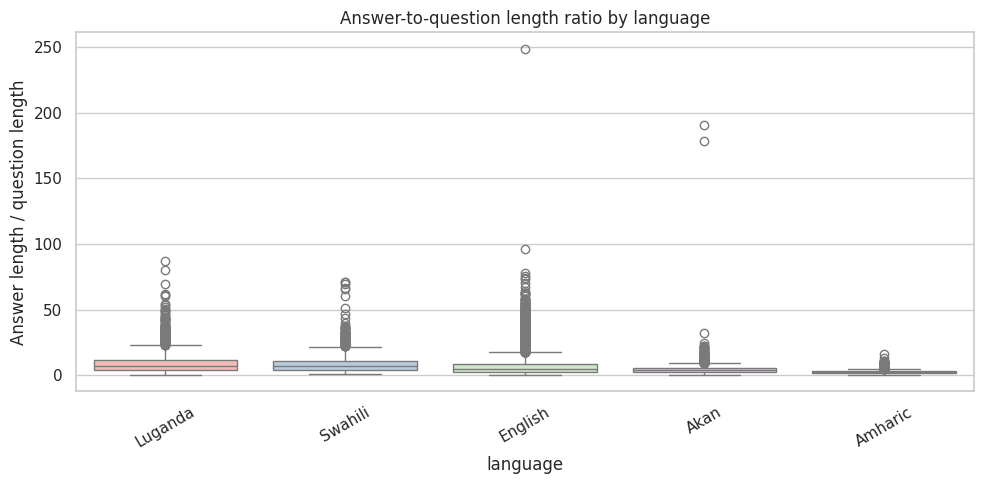

Saved: /content/multilingual-health-qa/figures/eda_question_length_by_subset.png


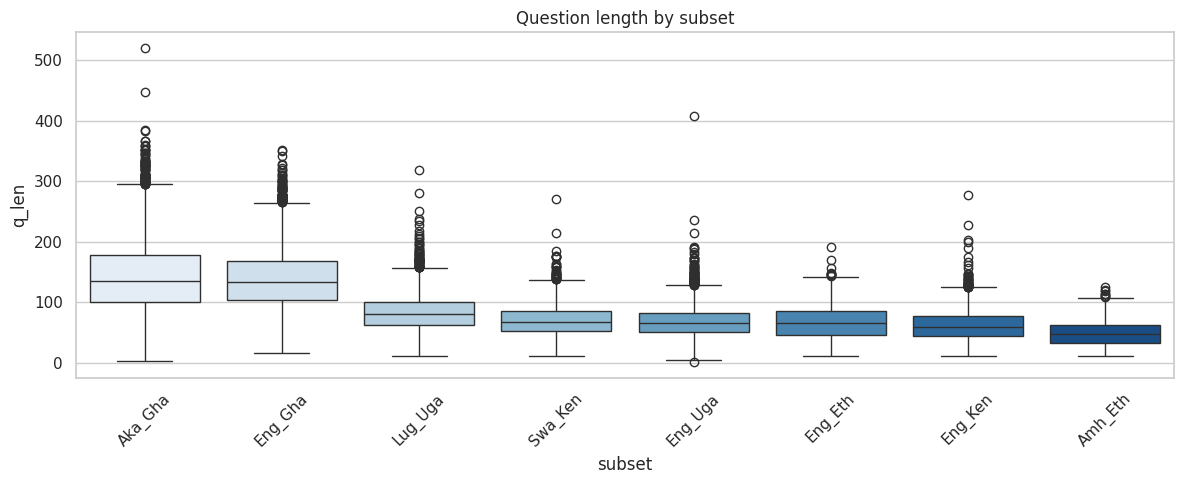

Saved: /content/multilingual-health-qa/figures/eda_answer_length_cdf.png


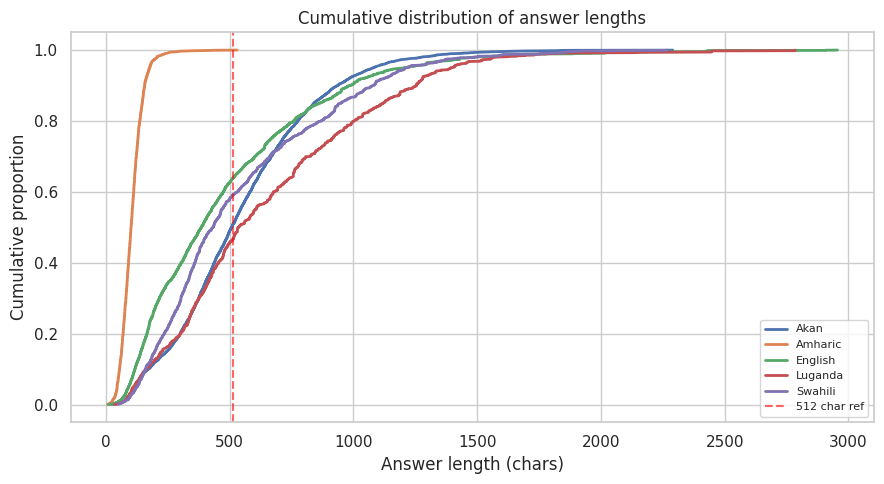

Saved: /content/multilingual-health-qa/figures/eda_language_country_heatmap.png


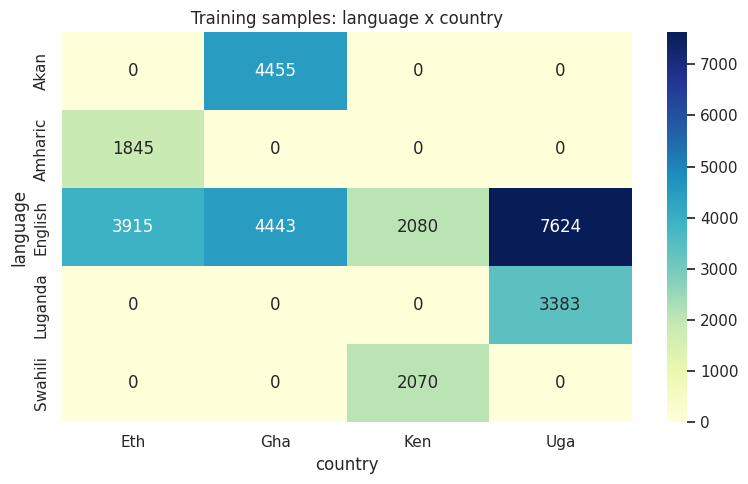

Saved: /content/multilingual-health-qa/figures/eda_duplicate_questions.png


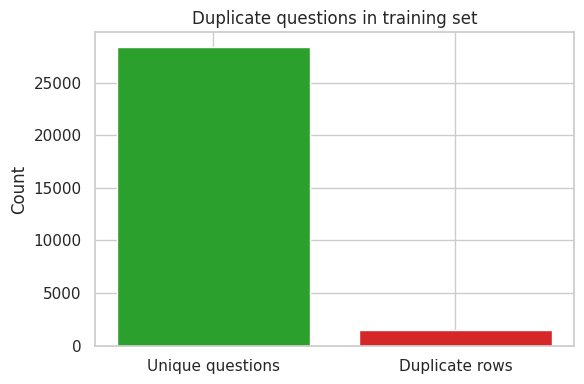


Duplicate Q&A breakdown:
  singleton questions (1 row each)      : 26,869
  repeated Q with identical A           : 284 questions / 568 rows
  repeated Q with different answers       : 1,184 questions / 2,378 rows
  exact Q+A duplicate groups              : 284
Saved: /content/multilingual-health-qa/figures/eda_duplicate_qa_taxonomy.png


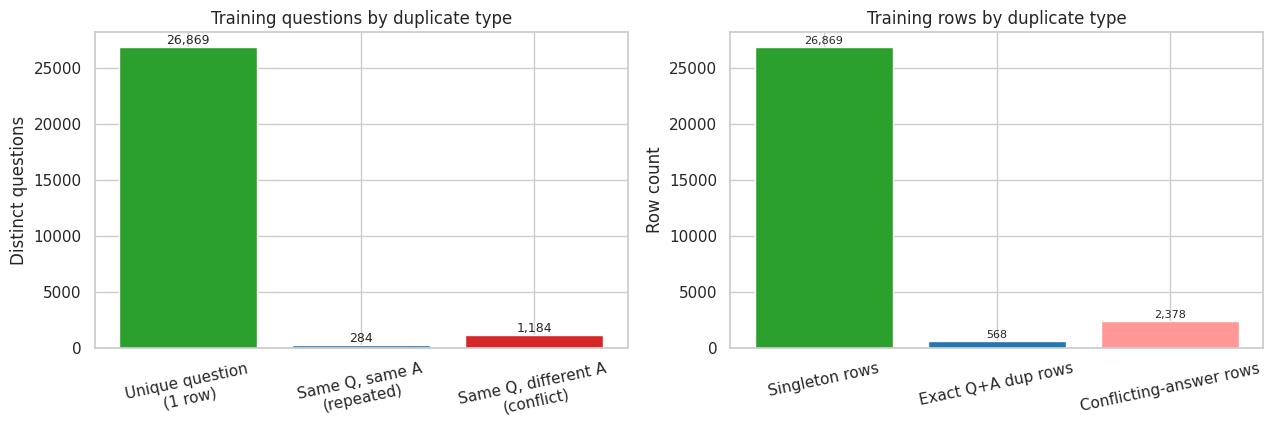

Saved: /content/multilingual-health-qa/figures/eda_exact_qa_duplicate_distribution.png


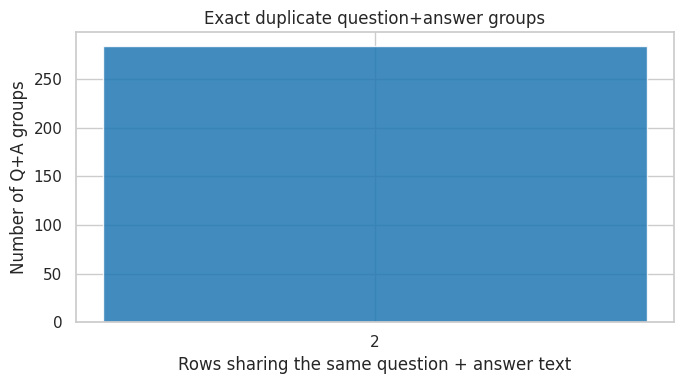


Sample exact duplicate question+answer groups (top 5 by copy count):


,copies,subset(s),question,answer,IDs
0,2,"Eng_Ken, Eng_Uga",Will taking ARVs lead to me being cured from HIV?,"Antiretroviral therapy (ART) does not cure HIV (Human Immunodeficiency Virus), but it can effectively manage the vir...","ID_TR_Eng_Ken_C523B4E9, ID_TR_Eng_Uga_7D3A8826"
1,2,"Eng_Ken, Eng_Uga","A friend of mine is struggling with the fear of spreading HIV to other people, how best can I be of help?","If someone you know is struggling with the fear or feeling of spreading HIV to others, it's important to provide sup...","ID_TR_Eng_Ken_5B951652, ID_TR_Eng_Uga_4EDA31CC"
2,2,"Eng_Ken, Eng_Uga","After engaging in oral sex and brushing my teeth, is there a risk of contracting HIV/STI?",The risk of contracting HIV or other sexually transmitted infections (STIs) through oral sex is generally lower than...,"ID_TR_Eng_Ken_F9ADDE7D, ID_TR_Eng_Uga_F24E7FD6"
3,2,"Eng_Ken, Eng_Uga","After infection, how long does it take for HIV to be noticed in your blood?",It takes approximately three months after being infected before the HIV can be noticed in your blood using special l...,"ID_TR_Eng_Ken_735E8153, ID_TR_Eng_Uga_93C379FD"
4,2,"Eng_Ken, Eng_Uga",Are ARVs available everywhere?,"Antiretroviral therapy (ART), which is a combination of medications used to treat HIV (Human Immunodeficiency Virus)...","ID_TR_Eng_Ken_8C7AA939, ID_TR_Eng_Uga_ACBA60E2"



Sample questions with multiple different answers (top 3 by row count):


,n_rows,n_distinct_answers,question,answer_preview_1,answer_preview_2
0,4,4,How is HIV transmitted?,"This is a question about, HIV/AIDS. HIV is mainly transmitted through unprotected sex, sharing conta…","HIV is mainly transmitted through unprotected sex, sharing contaminated needles, blood transfusions …"
1,3,3,Can you describe some of the difficulties faced by those cohabiting with people affected by HIV/AIDS?,Living with a person who has HIV/AIDS can bring both unique challenges and opportunities for support…,Living with a person who has HIV/AIDS can bring both unique challenges and opportunities for support…
2,3,3,How is Trichomoniasis treated?,"This is a question about, Trichomoniasis. With oral medication (Metronidazole or Tinidazole).…",With oral medication (Metronidazole or Tinidazole).…


Saved: /content/multilingual-health-qa/figures/eda_test_subset_distribution.png


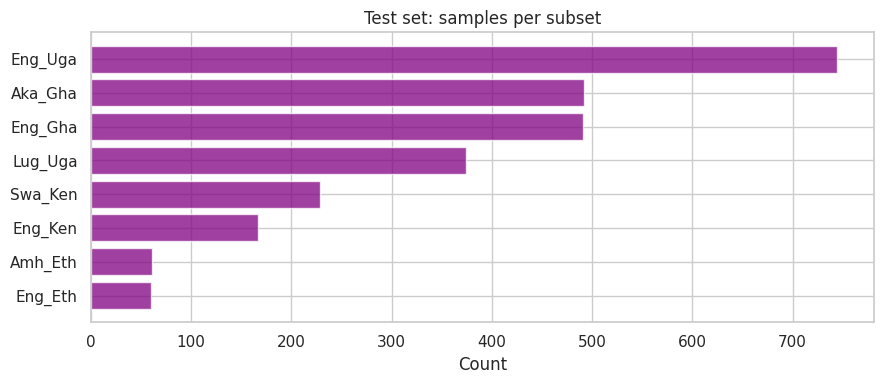

Extended EDA complete — 14 additional charts saved to /content/multilingual-health-qa/figures/


In [7]:
def save_fig(name):
    path = FIGURES_DIR / name
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f'Saved: {path}')
    return path


train['country'] = train[LANG_COL].str.split('_').str[-1]
val['country'] = val[LANG_COL].str.split('_').str[-1]
test['country'] = test[TEST_LANG_COL].str.split('_').str[-1]
train['qa_ratio'] = train['a_len'] / train['q_len'].clip(lower=1)
val['qa_ratio'] = val['a_len'] / val['q_len'].clip(lower=1)

# --- Chart 1: dataset split sizes ---
fig, ax = plt.subplots(figsize=(7, 4))
split_sizes = pd.Series({'Train': len(train), 'Val': len(val), 'Test': len(test)})
ax.bar(split_sizes.index, split_sizes.values, color=['#4C72B0', '#55A868', '#C44E52'])
ax.set_title('Dataset split sizes')
ax.set_ylabel('Rows')
for i, v in enumerate(split_sizes.values):
    ax.text(i, v + max(split_sizes) * 0.01, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
save_fig('eda_split_sizes.png')
plt.show()

# --- Chart 2: language share train vs val vs test ---
fig, ax = plt.subplots(figsize=(10, 5))
lang_compare = pd.DataFrame({
    'Train': train['language'].value_counts(normalize=True),
    'Val': val['language'].value_counts(normalize=True),
    'Test': test['language'].value_counts(normalize=True),
}).fillna(0) * 100
lang_compare.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Language share (%) across splits')
ax.set_ylabel('% of split')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Split')
plt.tight_layout()
save_fig('eda_language_share_splits.png')
plt.show()

# --- Chart 3: country distribution (train) ---
fig, ax = plt.subplots(figsize=(8, 4))
country_counts = train['country'].value_counts()
ax.bar(country_counts.index, country_counts.values, color='teal', alpha=0.85)
ax.set_title('Training samples per country code')
ax.set_ylabel('Count')
plt.tight_layout()
save_fig('eda_country_distribution.png')
plt.show()

# --- Chart 4: script distribution pie ---
fig, ax = plt.subplots(figsize=(6, 6))
script_counts = train['script'].value_counts()
ax.pie(script_counts.values, labels=script_counts.index, autopct='%1.1f%%', startangle=90)
ax.set_title('Training samples by script')
plt.tight_layout()
save_fig('eda_script_pie.png')
plt.show()

# --- Chart 5: question length KDE by language ---
fig, ax = plt.subplots(figsize=(10, 5))
for lang in train['language'].unique():
    subset = train.loc[train['language'] == lang, 'q_len']
    sns.kdeplot(subset, ax=ax, label=lang, linewidth=2)
ax.set_title('Question length density by language')
ax.set_xlabel('Question length (chars)')
ax.legend()
plt.tight_layout()
save_fig('eda_question_length_kde.png')
plt.show()

# --- Chart 6: answer length KDE by language ---
fig, ax = plt.subplots(figsize=(10, 5))
for lang in train['language'].unique():
    subset = train.loc[train['language'] == lang, 'a_len']
    sns.kdeplot(subset, ax=ax, label=lang, linewidth=2)
ax.set_title('Answer length density by language')
ax.set_xlabel('Answer length (chars)')
ax.legend()
plt.tight_layout()
save_fig('eda_answer_length_kde.png')
plt.show()

# --- Chart 7: QA length ratio by language ---
fig, ax = plt.subplots(figsize=(10, 5))
ratio_order = train.groupby('language')['qa_ratio'].median().sort_values(ascending=False).index
sns.boxplot(data=train, x='language', y='qa_ratio', order=ratio_order, ax=ax, palette='Pastel1')
ax.set_title('Answer-to-question length ratio by language')
ax.set_ylabel('Answer length / question length')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
save_fig('eda_qa_ratio_boxplot.png')
plt.show()

# --- Chart 8: question length by subset ---
fig, ax = plt.subplots(figsize=(12, 5))
q_order = train.groupby('subset')['q_len'].median().sort_values(ascending=False).index
sns.boxplot(data=train, x='subset', y='q_len', order=q_order, ax=ax, palette='Blues')
ax.set_title('Question length by subset')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
save_fig('eda_question_length_by_subset.png')
plt.show()

# --- Chart 9: cumulative answer length distribution ---
fig, ax = plt.subplots(figsize=(9, 5))
for lang in train['language'].unique():
    sorted_lens = np.sort(train.loc[train['language'] == lang, 'a_len'].values)
    y = np.arange(1, len(sorted_lens) + 1) / len(sorted_lens)
    ax.plot(sorted_lens, y, label=lang, linewidth=2)
ax.axvline(512, color='red', linestyle='--', alpha=0.6, label='512 char ref')
ax.set_title('Cumulative distribution of answer lengths')
ax.set_xlabel('Answer length (chars)')
ax.set_ylabel('Cumulative proportion')
ax.legend(fontsize=8)
plt.tight_layout()
save_fig('eda_answer_length_cdf.png')
plt.show()

# --- Chart 10: language x country heatmap ---
fig, ax = plt.subplots(figsize=(8, 5))
heatmap_data = pd.crosstab(train['language'], train['country'])
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGnBu', ax=ax)
ax.set_title('Training samples: language x country')
plt.tight_layout()
save_fig('eda_language_country_heatmap.png')
plt.show()

# --- Chart 11: duplicate vs unique questions ---
fig, ax = plt.subplots(figsize=(6, 4))
dup_unique = pd.Series({
    'Unique questions': train[QUESTION_COL].nunique(),
    'Duplicate rows': int(train[QUESTION_COL].duplicated().sum()),
})
ax.bar(dup_unique.index, dup_unique.values, color=['#2ca02c', '#d62728'])
ax.set_title('Duplicate questions in training set')
ax.set_ylabel('Count')
plt.tight_layout()
save_fig('eda_duplicate_questions.png')
plt.show()

# --- Chart 11b–11c: duplicate Q&A taxonomy and samples ---
SAMPLE_DUP_QA = 5
SAMPLE_CONFLICT = 3

train['_q_norm'] = train[QUESTION_COL].astype(str).str.strip()
train['_a_norm'] = train[ANSWER_COL].astype(str).str.strip()

qa_group_sizes = (
    train.groupby(['_q_norm', '_a_norm'], dropna=False)
    .size()
    .reset_index(name='row_count')
)
exact_qa_dup_groups = qa_group_sizes[qa_group_sizes['row_count'] > 1].copy()

q_meta = (
    train.groupby('_q_norm')
    .agg(n_rows=(QUESTION_COL, 'size'), n_answers=('_a_norm', 'nunique'))
    .reset_index()
)
singleton_questions = int((q_meta['n_rows'] == 1).sum())
repeat_same_answer = int(((q_meta['n_rows'] > 1) & (q_meta['n_answers'] == 1)).sum())
repeat_conflicting = int((q_meta['n_answers'] > 1).sum())
rows_exact_qa_dup = int(exact_qa_dup_groups['row_count'].sum()) if len(exact_qa_dup_groups) else 0
rows_conflicting = int(q_meta.loc[q_meta['n_answers'] > 1, 'n_rows'].sum())

print('\nDuplicate Q&A breakdown:')
print(f'  singleton questions (1 row each)      : {singleton_questions:,}')
print(f'  repeated Q with identical A           : {repeat_same_answer:,} questions / {rows_exact_qa_dup:,} rows')
print(f'  repeated Q with different answers       : {repeat_conflicting:,} questions / {rows_conflicting:,} rows')
print(f'  exact Q+A duplicate groups              : {len(exact_qa_dup_groups):,}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
question_cats = pd.Series({
    'Unique question\n(1 row)': singleton_questions,
    'Same Q, same A\n(repeated)': repeat_same_answer,
    'Same Q, different A\n(conflict)': repeat_conflicting,
})
axes[0].bar(question_cats.index, question_cats.values, color=['#2ca02c', '#1f77b4', '#d62728'])
axes[0].set_title('Training questions by duplicate type')
axes[0].set_ylabel('Distinct questions')
for i, v in enumerate(question_cats.values):
    axes[0].text(i, v + max(question_cats.values) * 0.01, f'{v:,}', ha='center', fontsize=9)
axes[0].tick_params(axis='x', rotation=12)

row_cats = pd.Series({
    'Singleton rows': singleton_questions,
    'Exact Q+A dup rows': rows_exact_qa_dup,
    'Conflicting-answer rows': rows_conflicting,
})
axes[1].bar(row_cats.index, row_cats.values, color=['#2ca02c', '#1f77b4', '#ff9896'])
axes[1].set_title('Training rows by duplicate type')
axes[1].set_ylabel('Row count')
for i, v in enumerate(row_cats.values):
    axes[1].text(i, v + max(row_cats.values) * 0.01, f'{v:,}', ha='center', fontsize=8)
axes[1].tick_params(axis='x', rotation=12)
plt.tight_layout()
save_fig('eda_duplicate_qa_taxonomy.png')
plt.show()

if not exact_qa_dup_groups.empty:
    copy_dist = exact_qa_dup_groups['row_count'].value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(copy_dist.index.astype(str), copy_dist.values, color='#1f77b4', alpha=0.85)
    ax.set_xlabel('Rows sharing the same question + answer text')
    ax.set_ylabel('Number of Q+A groups')
    ax.set_title('Exact duplicate question+answer groups')
    plt.tight_layout()
    save_fig('eda_exact_qa_duplicate_distribution.png')
    plt.show()

    print(f'\nSample exact duplicate question+answer groups (top {SAMPLE_DUP_QA} by copy count):')
    top_dup = exact_qa_dup_groups.sort_values('row_count', ascending=False).head(SAMPLE_DUP_QA)
    dup_samples = []
    for _, grp in top_dup.iterrows():
        mask = (train['_q_norm'] == grp['_q_norm']) & (train['_a_norm'] == grp['_a_norm'])
        ids = train.loc[mask, 'ID'].tolist()
        dup_samples.append({
            'copies': int(grp['row_count']),
            'subset(s)': ', '.join(sorted(train.loc[mask, LANG_COL].unique())),
            'question': grp['_q_norm'][:140] + ('…' if len(grp['_q_norm']) > 140 else ''),
            'answer': grp['_a_norm'][:140] + ('…' if len(grp['_a_norm']) > 140 else ''),
            'IDs': ', '.join(ids[:3]) + ('…' if len(ids) > 3 else ''),
        })
    display(pd.DataFrame(dup_samples))
else:
    print('\nNo exact duplicate question+answer groups found.')

conflict_qs = q_meta[q_meta['n_answers'] > 1].sort_values('n_rows', ascending=False).head(SAMPLE_CONFLICT)
if not conflict_qs.empty:
    print(f'\nSample questions with multiple different answers (top {SAMPLE_CONFLICT} by row count):')
    conflict_samples = []
    for _, row in conflict_qs.iterrows():
        q = row['_q_norm']
        examples = train.loc[train['_q_norm'] == q, [LANG_COL, ANSWER_COL]].drop_duplicates().head(2)
        conflict_samples.append({
            'n_rows': int(row['n_rows']),
            'n_distinct_answers': int(row['n_answers']),
            'question': q[:120] + ('…' if len(q) > 120 else ''),
            'answer_preview_1': str(examples.iloc[0][ANSWER_COL])[:100] + '…',
            'answer_preview_2': str(examples.iloc[1][ANSWER_COL])[:100] + '…' if len(examples) > 1 else '',
        })
    display(pd.DataFrame(conflict_samples))

train.drop(columns=['_q_norm', '_a_norm'], inplace=True)

# --- Chart 12: test subset distribution ---
fig, ax = plt.subplots(figsize=(9, 4))
test_subset = test[TEST_LANG_COL].value_counts()
ax.barh(test_subset.index[::-1], test_subset.values[::-1], color='purple', alpha=0.75)
ax.set_title('Test set: samples per subset')
ax.set_xlabel('Count')
plt.tight_layout()
save_fig('eda_test_subset_distribution.png')
plt.show()

print(f'Extended EDA complete — 14 additional charts saved to {FIGURES_DIR}/')


### 6.1 — From EDA findings to design decisions

The table below links observed data patterns to pipeline choices tested in Sections 10–14.

| EDA finding | Implication | Pipeline decision |
|---|---|---|
| Five languages across two scripts (Latin and Ge'ez) | Monolingual tokenisers fail on Amharic | Multilingual embeddings (`paraphrase-multilingual-mpnet-base-v2`) |
| Answers are 5–7× longer than questions (mean Q ≈ 90, A ≈ 490 chars) | Generation must produce long text; retrieval copies expert answers | Prefer retrieval over zero-shot generation |
| Class imbalance: English ≈ 60%, Amharic ≈ 6% | Weak subsets need targeted blending | Per-subset semantic / TF-IDF routing weights |
| `subset` encodes language and country | Same language varies by country | Per-subset retrieval indexes |
| ≈ 1,500 duplicate question rows; 1,183 questions with conflicting answers | Exact match is unreliable | Semantic top-1 retrieval; conflict-aware dedup (E21) |
| Zero train–validation question overlap | Official validation is a fair benchmark | Use `Val.csv` for all local comparisons |
| English subsets score highest; `Amh_Eth` lowest | Script and data volume drive difficulty | Higher TF-IDF weight for weak subsets |

## 7 — Text preprocessing

Preprocessing is intentionally **minimal** to preserve linguistic content in low-resource languages.

| Step | Function | Rationale |
|---|---|---|
| Whitespace normalisation | `clean_text()` | Removes leading/trailing spaces; handles null values |
| Empty-row removal | filter on `input` / `output` | Drops rows with missing question or answer text |
| Exact Q+A deduplication | `drop_duplicates` on `input` + `output` | Removes repeated training rows (keeps first occurrence) |
| Language mapping | `subset_to_language_name()` | Converts subset codes to readable names for LLM prompts |
| Script mapping | `subset_to_script()` | Supports EDA and documentation |

No stemming, lowercasing, or language-specific tokenisation is applied. Multilingual models receive raw Unicode text.

> **Note:** Questions with identical wording but different answers are retained — only exact question+answer copies are removed.

In [8]:
def clean_text(x):
    """Strip whitespace and handle null values."""
    if pd.isna(x):
        return ''
    return str(x).strip()

train[QUESTION_COL]      = train[QUESTION_COL].map(clean_text)
train[ANSWER_COL]        = train[ANSWER_COL].map(clean_text)
test[TEST_QUESTION_COL]  = test[TEST_QUESTION_COL].map(clean_text)
val[QUESTION_COL]        = val[QUESTION_COL].map(clean_text)
val[ANSWER_COL]          = val[ANSWER_COL].map(clean_text)

train = train[(train[QUESTION_COL] != '') & (train[ANSWER_COL] != '')].reset_index(drop=True)
test  = test[test[TEST_QUESTION_COL]  != ''].reset_index(drop=True)
val   = val[(val[QUESTION_COL] != '') & (val[ANSWER_COL] != '')].reset_index(drop=True)

_n_train_before_dedup = len(train)
train = (
    train
    .drop_duplicates(subset=[QUESTION_COL, ANSWER_COL], keep='first')
    .reset_index(drop=True)
)
_n_exact_qa_dropped = _n_train_before_dedup - len(train)
if _n_exact_qa_dropped:
    print(f'Dropped {_n_exact_qa_dropped:,} exact duplicate question+answer rows from training set')

print(f'Cleaned train shape : {train.shape}')
print(f'Cleaned val shape   : {val.shape}')
print(f'Cleaned test shape  : {test.shape}')

Dropped 284 exact duplicate question+answer rows from training set
Cleaned train shape : (29530, 10)
Cleaned val shape   : (6686, 10)
Cleaned test shape  : (2618, 6)


## 8 — Evaluation utilities (ROUGE)

Local evaluation uses **ROUGE-1** and **ROUGE-L** F1 scores computed on `Val.csv` via the `rouge-score` library.

| Function | Description |
|---|---|
| `compute_rouge()` | Aggregate ROUGE-1 and ROUGE-L F1 over predictions and references |
| `compute_rouge_by_language()` | Per-subset ROUGE breakdown |
| `print_run_summary()` | Formatted run report with per-subset metrics |

These metrics guide model selection during development. The Zindi public leaderboard uses a hidden test set and may differ from local ROUGE on `Val.csv`.

In [9]:
try:
    from rouge_score import rouge_scorer

    class WhitespaceTokenizer:
        def tokenize(self, text):
            if text is None:
                return []
            return str(text).strip().split()

    def compute_rouge(predictions, references):
        scorer = rouge_scorer.RougeScorer(
            ['rouge1', 'rougeL'],
            tokenizer=WhitespaceTokenizer(),
            use_stemmer=False,
        )
        r1_scores, rl_scores = [], []
        for pred, ref in zip(predictions, references):
            score = scorer.score(str(ref), str(pred))
            r1_scores.append(score['rouge1'].fmeasure)
            rl_scores.append(score['rougeL'].fmeasure)
        return {
            'rouge1_f1': float(np.mean(r1_scores)) if r1_scores else 0.0,
            'rougeL_f1': float(np.mean(rl_scores)) if rl_scores else 0.0,
        }

    def compute_rouge_by_language(predictions, references, languages):
        results = {}
        lang_arr = np.array(languages)
        for lang in np.unique(lang_arr):
            mask = lang_arr == lang
            preds_l = [p for p, m in zip(predictions, mask) if m]
            refs_l  = [r for r, m in zip(references, mask) if m]
            results[lang] = compute_rouge(preds_l, refs_l)
        return pd.DataFrame(results).T

    def print_run_summary(name, predictions, references, languages=None, min_answer_len=200):
        """Print ROUGE, length stats, and optional per-subset breakdown."""
        preds = [str(p) for p in predictions]
        refs = [str(r) for r in references]
        m = compute_rouge(preds, refs)
        lens = [len(p) for p in preds]
        short_n = sum(1 for L in lens if L < min_answer_len)
        empty_n = sum(1 for p in preds if not p.strip())

        print(f'\n{"=" * 60}')
        print(f'  {name}')
        print(f'{"=" * 60}')
        print(f'  ROUGE-1 F1 : {m["rouge1_f1"]:.4f}')
        print(f'  ROUGE-L F1 : {m["rougeL_f1"]:.4f}')
        print(f'  Predictions: {len(preds):,}')
        print(f'  Avg length : {np.mean(lens):.0f} chars  (median {np.median(lens):.0f})')
        print(f'  Short (<{min_answer_len}): {short_n:,}  |  Empty: {empty_n:,}')
        if languages is not None:
            print('  Per-subset ROUGE:')
            display(compute_rouge_by_language(preds, refs, languages).round(4))
        return m

    print('ROUGE scorer loaded')
except ImportError:
    print('rouge-score not installed. Run: pip install rouge-score')
    compute_rouge = None
    print_run_summary = None


ROUGE scorer loaded


## 9 — Experiment tracker

Ten experiments (IDs **E01**, **E07**, **E16**–**E23**) record the intervention, rationale, validation outcome, and actionable insight. Each experiment has dedicated markdown and code cells in Sections 10–14.

### Usage

Call `tracker.log()` after each experiment. Results append to `experiment_log.json` and can be exported as a summary table (Section 16).

### Experiment plan

| Exp | ID | Description | Category | Best Val ROUGE-1 |
|---|---|---|---|---:|
| 1 | E01 | TF-IDF global retrieval | baseline | 0.427 |
| 2 | E07 | Zero-shot mT5-small | baseline | 0.015 |
| 3 | E16 | Semantic routing (mpnet, hybrid weights) | semantic | 0.471 |
| 4 | E17 | Per-subset hybrid weight tuning | semantic | 0.474 |
| 5 | E18 | Char n-gram TF-IDF in hybrid leg | semantic | **0.474** |
| 6 | E20 | Min-max score normalization | semantic | 0.472 |
| 7 | E21 | Conflict-aware index (dedup + exact match) | semantic | 0.473 |
| 8 | E22 | Similarity-threshold TF-IDF fallback | semantic | 0.474 |
| 9 | E23 | Cross-subset fallback (Amh → Eng) | semantic | 0.474 |
| 10 | E19 | Multilingual E5-base encoder (optional) | semantic | 0.474 |

In [10]:
class ExperimentTracker:
    """Log and compare experiments."""

    def __init__(self, path=EXPERIMENT_LOG_PATH):
        self.path = Path(path)
        self.records = []
        if self.path.exists():
            self.records = json.loads(self.path.read_text())

    def log(self, experiment_id, name, change, rationale, rouge1=None, rougel=None,
            notes='', runtime_min=None, category=''):
        record = {
            'id': experiment_id,
            'name': name,
            'category': category,
            'change': change,
            'rationale': rationale,
            'rouge1_f1': rouge1,
            'rougeL_f1': rougel,
            'notes': notes,
            'runtime_min': runtime_min,
            'timestamp': datetime.utcnow().isoformat() + 'Z',
        }
        self.records = [r for r in self.records if r['id'] != experiment_id]
        self.records.append(record)
        self.path.write_text(json.dumps(self.records, indent=2))
        print(f"Logged experiment {experiment_id}: {name}")
        return record

    def to_dataframe(self):
        cols = ['id', 'name', 'category', 'change', 'rouge1_f1', 'rougeL_f1', 'notes']
        if not self.records:
            return pd.DataFrame(columns=cols)
        return pd.DataFrame(self.records)[cols].sort_values('id')

tracker = ExperimentTracker()

PLANNED_EXPERIMENTS = pd.DataFrame([
    {'id': 'E01', 'name': 'TF-IDF global retrieval', 'category': 'baseline', 'change': 'Char n-gram TF-IDF, single global index'},
    {'id': 'E07', 'name': 'Zero-shot mT5-small', 'category': 'baseline', 'change': 'Language-conditioned prompt, beam search'},
    {'id': 'E16', 'name': 'Semantic routing (baseline)', 'category': 'semantic', 'change': 'mpnet top-1 + per-subset hybrid weights'},
    {'id': 'E17', 'name': 'Hybrid weight tuning', 'category': 'semantic', 'change': 'Grid-search TF-IDF blend per weak subset on Val'},
    {'id': 'E18', 'name': 'Char-TF-IDF hybrid', 'category': 'semantic', 'change': 'Char 3–5 n-grams in hybrid leg for script-heavy subsets'},
    {'id': 'E19', 'name': 'E5-base encoder', 'category': 'semantic', 'change': 'intfloat/multilingual-e5-base with query/passage prefixes'},
    {'id': 'E20', 'name': 'Score normalization', 'category': 'semantic', 'change': 'Min-max normalize semantic and TF-IDF scores before blending'},
    {'id': 'E21', 'name': 'Conflict-aware retrieval', 'category': 'semantic', 'change': 'Question-level dedup + exact-match shortcut'},
    {'id': 'E22', 'name': 'Similarity threshold fallback', 'category': 'semantic', 'change': 'Low-confidence semantic → pure TF-IDF'},
    {'id': 'E23', 'name': 'Cross-subset fallback', 'category': 'semantic', 'change': 'Amh_Eth searches Eng_Eth when semantic score is weak'},
])
print(f'Planned experiments: {len(PLANNED_EXPERIMENTS)} total')
display(PLANNED_EXPERIMENTS)


Planned experiments: 10 total


,id,name,category,change
0,E01,TF-IDF global retrieval,baseline,"Char n-gram TF-IDF, single global index"
1,E07,Zero-shot mT5-small,baseline,"Language-conditioned prompt, beam search"
2,E16,Semantic routing (baseline),semantic,mpnet top-1 + per-subset hybrid weights
3,E17,Hybrid weight tuning,semantic,Grid-search TF-IDF blend per weak subset on Val
4,E18,Char-TF-IDF hybrid,semantic,Char 3–5 n-grams in hybrid leg for script-heavy subsets
5,E19,E5-base encoder,semantic,intfloat/multilingual-e5-base with query/passage prefixes
6,E20,Score normalization,semantic,Min-max normalize semantic and TF-IDF scores before blending
7,E21,Conflict-aware retrieval,semantic,Question-level dedup + exact-match shortcut
8,E22,Similarity threshold fallback,semantic,Low-confidence semantic → pure TF-IDF
9,E23,Cross-subset fallback,semantic,Amh_Eth searches Eng_Eth when semantic score is weak


## 10 — Experiment 1: TF-IDF retrieval (`E01`)

Establish a **sparse retrieval lower bound** before neural models.

**Method:** Character n-gram TF-IDF retrieves the nearest training question; the paired answer is returned verbatim. Character n-grams operate across Latin and Ge'ez scripts without language-specific tokenisation.

**Design choice:** A single global index is used (`group_col=None`). Early tests showed per-subset TF-IDF did not improve validation ROUGE over a global index, so the simpler baseline is retained.

In [11]:
class TfidfRetrievalAnswerer:
    def __init__(self, question_col, answer_col, group_col=None,
                 ngram_range=(3, 5), max_features=200_000):
        self.question_col = question_col
        self.answer_col   = answer_col
        self.group_col    = group_col
        self.ngram_range  = ngram_range
        self.max_features = max_features
        self.models       = {}
        self.global_model = None

    def _fit_single(self, df):
        vectorizer = TfidfVectorizer(
            analyzer='char_wb', ngram_range=self.ngram_range,
            min_df=1, max_features=self.max_features, lowercase=False,
        )
        questions = df[self.question_col].fillna('').astype(str).tolist()
        answers   = df[self.answer_col].fillna('').astype(str).tolist()
        X = vectorizer.fit_transform(questions)
        nn = NearestNeighbors(n_neighbors=1, metric='cosine')
        nn.fit(X)
        return {'vectorizer': vectorizer, 'nn': nn,
                'answers': np.array(answers, dtype=object),
                'questions': np.array(questions, dtype=object)}

    def fit(self, df):
        self.global_model = self._fit_single(df)
        if self.group_col and self.group_col in df.columns:
            for group, sub in df.groupby(self.group_col):
                if len(sub) >= 2:
                    self.models[group] = self._fit_single(sub)
        print(f'  Fitted global model + {len(self.models)} group model(s)')
        return self

    def _predict_one_from_model(self, question, model):
        Xq = model['vectorizer'].transform([question])
        dist, idx = model['nn'].kneighbors(Xq, n_neighbors=1)
        return model['answers'][idx[0][0]], 1 - float(dist[0][0]), model['questions'][idx[0][0]]

    def predict_one(self, question, group=None):
        model = self.models.get(group, self.global_model) if group is not None else self.global_model
        return self._predict_one_from_model(question, model)

    def predict(self, df, question_col, group_col=None):
        outputs, similarities, matched = [], [], []
        for _, row in df.iterrows():
            question = clean_text(row[question_col])
            group = row[group_col] if group_col and group_col in df.columns else None
            answer, sim, matched_q = self.predict_one(question, group)
            outputs.append(answer)
            similarities.append(sim)
            matched.append(matched_q)
        return outputs, similarities, matched

print('TfidfRetrievalAnswerer defined')

TfidfRetrievalAnswerer defined


### Experiment 1 — TF-IDF global retrieval (`E01`)

| | |
|---|---|
| **Objective** | Establish a sparse retrieval lower bound with a single index across all subsets |
| **Method** | Char n-gram TF-IDF (`group_col=None`); nearest-neighbour answer transfer on `Val.csv` |
| **Evaluation** | ROUGE-1 and ROUGE-L F1 on the full validation set |

#### Result

| Metric | Value |
|---|---:|
| ROUGE-1 F1 | 0.427 |
| ROUGE-L F1 | 0.374 |

#### Interpretation

TF-IDF alone achieves moderate ROUGE by copying in-corpus expert answers. This confirms retrieval is viable but leaves room for semantic matching improvements (E16).

Training TF-IDF retrieval (E01: global index)...
  Fitted global model + 0 group model(s)

TF-IDF (E01) — Validation ROUGE
   ROUGE-1 F1 : 0.4275
   ROUGE-L F1 : 0.3738

Per-subset ROUGE:


,rouge1_f1,rougeL_f1
Aka_Gha,0.2869,0.1693
Amh_Eth,0.1529,0.1433
Eng_Eth,0.5073,0.4883
Eng_Gha,0.2607,0.1739
Eng_Ken,0.5982,0.5647
Eng_Uga,0.5438,0.5051
Lug_Uga,0.5047,0.4813
Swa_Ken,0.6093,0.5735


Logged experiment E01: TF-IDF global retrieval
Saved: /content/multilingual-health-qa/figures/eval_tfidf_by_subset.png


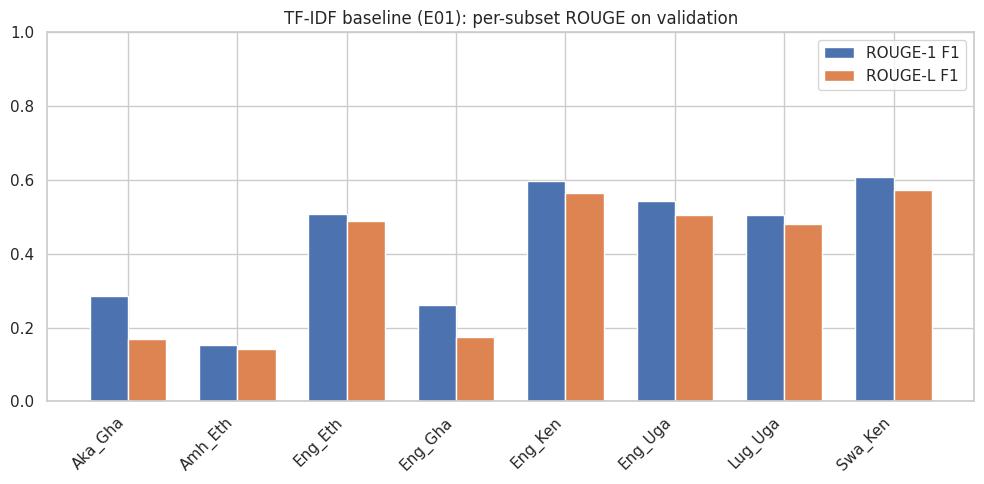


Generating TF-IDF test predictions...
Generated 2,618 test predictions


In [12]:
print('Training TF-IDF retrieval (E01: global index)...')
answerer_global = TfidfRetrievalAnswerer(
    question_col=QUESTION_COL, answer_col=ANSWER_COL, group_col=None,
).fit(train)

val_pred_global, val_sim_global, _ = answerer_global.predict(
    val, question_col=QUESTION_COL, group_col=LANG_COL,
)

if compute_rouge:
    metrics_e01 = compute_rouge(val_pred_global, val[ANSWER_COL].tolist())
    print(f'\nTF-IDF (E01) — Validation ROUGE')
    print(f'   ROUGE-1 F1 : {metrics_e01["rouge1_f1"]:.4f}')
    print(f'   ROUGE-L F1 : {metrics_e01["rougeL_f1"]:.4f}')

    lang_metrics = compute_rouge_by_language(
        val_pred_global, val[ANSWER_COL].tolist(), val[LANG_COL].tolist()
    )
    print('\nPer-subset ROUGE:')
    display(lang_metrics.round(4))

    tracker.log(
        experiment_id='E01',
        name='TF-IDF global retrieval',
        category='baseline',
        change='Char n-gram TF-IDF, single global index',
        rationale='Sparse retrieval lower bound; global index beats per-subset on Val',
        rouge1=metrics_e01['rouge1_f1'],
        rougel=metrics_e01['rougeL_f1'],
    )

    if not lang_metrics.empty:
        fig, ax = plt.subplots(figsize=(10, 5))
        plot_df = lang_metrics.reset_index().rename(columns={'index': 'subset'})
        x = np.arange(len(plot_df))
        w = 0.35
        ax.bar(x - w/2, plot_df['rouge1_f1'], w, label='ROUGE-1 F1')
        ax.bar(x + w/2, plot_df['rougeL_f1'], w, label='ROUGE-L F1')
        ax.set_xticks(x)
        ax.set_xticklabels(plot_df['subset'], rotation=45, ha='right')
        ax.set_ylim(0, 1)
        ax.set_title('TF-IDF baseline (E01): per-subset ROUGE on validation')
        ax.legend()
        plt.tight_layout()
        save_fig('eval_tfidf_by_subset.png')
        plt.show()

print('\nGenerating TF-IDF test predictions...')
test_pred_tfidf, test_sim, _ = answerer_global.predict(
    test, question_col=TEST_QUESTION_COL, group_col=TEST_LANG_COL,
)
print(f'Generated {len(test_pred_tfidf):,} test predictions')


## 11 — Experiment 2: Zero-shot multilingual LLM (`E07`)

### Objective

Test whether a compact multilingual seq2seq model can answer health questions **without retrieval or fine-tuning**, establishing an upper-bound reference for generative approaches.

| | |
|---|---|
| **Model** | `google/mt5-small` |
| **Prompting** | Language-conditioned prefix (`USE_LANGUAGE_PROMPT=True`) |
| **Decoding** | Beam search (4 beams) |
| **Protocol** | 200-row validation sample; full test export for submission |
| **Runtime** | Requires **T4 GPU** in Colab |

#### Result

| Metric | Value |
|---|---:|
| ROUGE-1 F1 | 0.015 |
| ROUGE-L F1 | 0.014 |

#### Interpretation

Zero-shot generation fails on this task: answers are long, domain-specific, and poorly approximated without in-domain fine-tuning. This result motivates the retrieval-first design in Section 13.

### Inference settings

| Parameter | Default | Notes |
|---|---|---|
| `MAX_INPUT_LENGTH` | 256 | Based on question length distribution |
| `MAX_OUTPUT_LENGTH` | 512 | Based on answer length distribution |
| `NUM_BEAMS` | 4 | Beam search for longer answers |
| `USE_LANGUAGE_PROMPT` | True | Prepends target language to the input |

In [13]:
import sys
import subprocess
import importlib.util

# Install mT5 tokenizer deps into *this* kernel's Python (before importing transformers).
subprocess.check_call(
    [sys.executable, '-m', 'pip', 'install', '-q', 'protobuf', 'sentencepiece']
)
importlib.invalidate_caches()
import google.protobuf  # noqa: F401
import sentencepiece  # noqa: F401

# transformers caches sentencepiece availability at first import — refresh after install.
import transformers.utils.import_utils as _tf_import_utils
_tf_import_utils._sentencepiece_available = _tf_import_utils._is_package_available('sentencepiece')

import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

MODEL_NAME = 'google/mt5-small'

MAX_INPUT_LENGTH  = 256
MAX_OUTPUT_LENGTH = 512
BATCH_SIZE_LLM    = 8
NUM_BEAMS         = 4
USE_LANGUAGE_PROMPT = True

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
print(f'Model  : {MODEL_NAME}')
print(f'Language-conditioned prompts: {USE_LANGUAGE_PROMPT}')

Device : cuda
Model  : google/mt5-small
Language-conditioned prompts: True


In [14]:
print(f'Loading {MODEL_NAME}...')
try:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
except ValueError as exc:
    if 'protobuf' in str(exc).lower() or 'tiktoken' in str(exc).lower():
        raise RuntimeError(
            'Tokenizer load failed — re-run the cell above to install protobuf + sentencepiece, '
            'then re-run this cell.'
        ) from exc
    raise
model_llm = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if DEVICE == 'cuda' else torch.float32,
)
model_llm.gradient_checkpointing_enable()
model_llm = model_llm.to(DEVICE)
model_llm.eval()
print(f'Loaded {sum(p.numel() for p in model_llm.parameters()) / 1e6:.0f}M parameters on {DEVICE}')

Loading google/mt5-small...


tokenizer_config.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/553 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


pytorch_model.bin:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

Loaded 300M parameters on cuda


In [15]:
FALLBACK_ANSWER = 'Please consult a healthcare professional for personalised advice.'


def build_prompt(question: str, language: str = None) -> str:
    """
    Build seq2seq input. E07 uses language conditioning because EDA shows
    5 languages with imbalanced counts; explicit language tags reduce
    English-dominance bias during fine-tuning and inference.
    """
    q = str(question).strip()
    if USE_LANGUAGE_PROMPT and language:
        lang_name = subset_to_language_name(language)
        return f'answer health question in {lang_name}: {q}'
    return q


def generate_answers_batch(questions, languages=None, batch_size=BATCH_SIZE_LLM,
                           num_beams=NUM_BEAMS):
    if languages is None:
        languages = [None] * len(questions)
    all_answers = []
    n_batches = (len(questions) + batch_size - 1) // batch_size

    for batch_idx in range(n_batches):
        start = batch_idx * batch_size
        end = min(start + batch_size, len(questions))
        prompts = [build_prompt(q, l) for q, l in zip(questions[start:end], languages[start:end])]

        inputs = tokenizer(
            prompts, return_tensors='pt', padding=True,
            truncation=True, max_length=MAX_INPUT_LENGTH,
        ).to(DEVICE)

        with torch.no_grad():
            outputs = model_llm.generate(
                **inputs,
                max_new_tokens=MAX_OUTPUT_LENGTH,
                min_new_tokens=1,
                num_beams=num_beams,
                early_stopping=True,
                no_repeat_ngram_size=3,
            )

        decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        cleaned = [re.sub(r'<extra_id_\d+>', '', ans).strip() for ans in decoded]
        cleaned = [ans if ans else FALLBACK_ANSWER for ans in cleaned]
        all_answers.extend(cleaned)

        if (batch_idx + 1) % 10 == 0 or (batch_idx + 1) == n_batches:
            print(f'  Batch {batch_idx + 1}/{n_batches}')

    empty_n = sum(1 for a in all_answers if not str(a).strip())
    if empty_n:
        print(f'WARNING: {empty_n} empty predictions remain after fallback')
    return all_answers

print('Generation helpers defined')

Generation helpers defined


In [16]:
if 'tokenizer' not in globals() or 'model_llm' not in globals():
    raise RuntimeError('Run the model load cell above first (tokenizer / model_llm not defined).')

sample = val.head(3)
gen_sample = generate_answers_batch(
    sample[QUESTION_COL].tolist(),
    sample[LANG_COL].tolist() if LANG_COL else None,
    batch_size=3,
)
for idx, (_, row) in enumerate(sample.iterrows()):
    print(f'\n[{idx+1}] {row[LANG_COL]}')
    print(f'  Q: {row[QUESTION_COL][:100]}...')
    print(f'  Ref: {row[ANSWER_COL][:100]}...')
    print(f'  Gen: {gen_sample[idx][:100]}...')

  Batch 1/1

[1] Aka_Gha
  Q: Sɛn na nwomasua ne adwuma nteteeɛ boa akuo a eye mmabun a wɔ hia neaɛma sokoronko ne ohaw ahorow, at...
  Ref: Nhyehyɛeɛ aa ama ne mu so te sɛ senea aborɔfo ka no 'STEM' ne 'vocational training' se ɛbɛ adrɛse mm...
  Gen: ....

[2] Aka_Gha
  Q: Dɛn nti na ɛho hia sɛ mmabun te wɔn nna ne awo hokwan ahorow ase?...
  Ref: Nna ne awo hokwan ahorow a wɔte ase no ma mmabun tumi: Si gyinae a ɛfata wɔ wɔn nipadua, nna, ne abu...
  Gen: ?...

[3] Aka_Gha
  Q: Mɛyɛ dɛn atumi abɔ asisifo ho amanneɛ wɔ ɔkwan a etu mpɔn na ahobammɔ wom so, na anammɔn bɛn na metu...
  Ref: Ayayade ho nsɛm a wɔbɛbɔ ho amanneɛ yiye na ahobammɔ wom no hwehwɛ sɛ wɔyɛ nneɛma a edidi so yi: Wɔk...
  Gen: ....


Evaluating zero-shot LLM on 200 val examples...
  Batch 10/25
  Batch 20/25
  Batch 25/25

Zero-shot LLM - Validation ROUGE (google/mt5-small)
   ROUGE-1 F1 : 0.0153
   ROUGE-L F1 : 0.0144
Logged experiment E07: Zero-shot google/mt5-small (E07)


,rouge1_f1,rougeL_f1
Aka_Gha,0.0023,0.0023
Amh_Eth,0.0111,0.0111
Eng_Eth,0.0373,0.0373
Eng_Gha,0.0241,0.0233
Eng_Ken,0.0346,0.0315
Eng_Uga,0.0244,0.0205
Lug_Uga,0.0000,0.0000
Swa_Ken,0.0000,0.0000


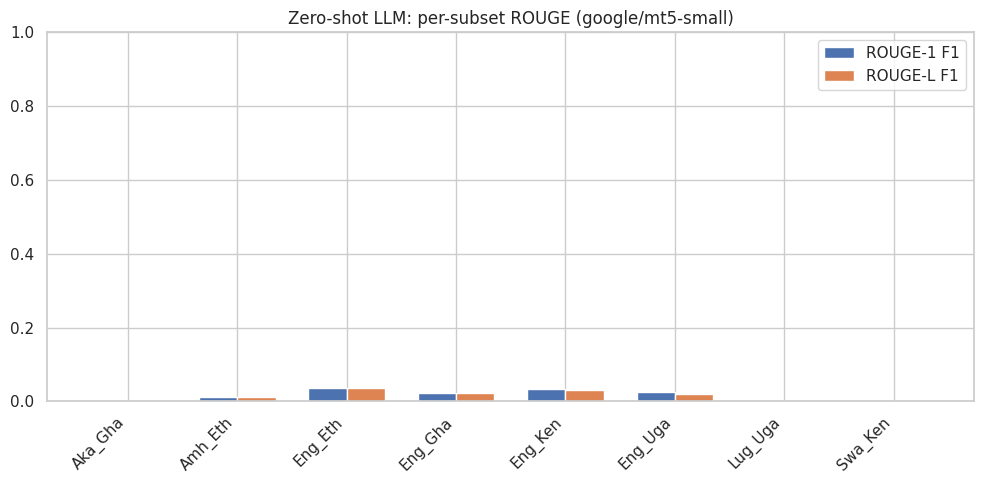

Saved: /content/multilingual-health-qa/figures/eval_zeroshot_rouge_by_subset.png


In [17]:
VALIDATION_SAMPLE_SIZE = 200

val_sample = val.sample(min(VALIDATION_SAMPLE_SIZE, len(val)), random_state=SEED) if VALIDATION_SAMPLE_SIZE else val
print(f'Evaluating zero-shot LLM on {len(val_sample)} val examples...')

val_questions = val_sample[QUESTION_COL].tolist()
val_languages = val_sample[LANG_COL].tolist() if LANG_COL else None
val_references = val_sample[ANSWER_COL].tolist()

val_predictions_llm = generate_answers_batch(val_questions, val_languages)

if compute_rouge:
    metrics_llm = compute_rouge(val_predictions_llm, val_references)
    print(f'\nZero-shot LLM - Validation ROUGE ({MODEL_NAME})')
    print(f'   ROUGE-1 F1 : {metrics_llm["rouge1_f1"]:.4f}')
    print(f'   ROUGE-L F1 : {metrics_llm["rougeL_f1"]:.4f}')

    tracker.log(
        experiment_id='E07',
        name=f'Zero-shot {MODEL_NAME} (E07)',
        change=f'Model={MODEL_NAME}, language_prompt={USE_LANGUAGE_PROMPT}, beams={NUM_BEAMS}',
        category='baseline',
        rationale='EDA: multilingual imbalance -> language-conditioned prompts; long answers -> beam search',
        rouge1=metrics_llm['rouge1_f1'], rougel=metrics_llm['rougeL_f1'],
    )

    llm_lang_metrics = compute_rouge_by_language(val_predictions_llm, val_references, val_sample[LANG_COL].tolist())
    display(llm_lang_metrics.round(4))

    fig, ax = plt.subplots(figsize=(10, 5))
    plot_df = llm_lang_metrics.reset_index().rename(columns={'index': 'subset'})
    x = np.arange(len(plot_df))
    w = 0.35
    ax.bar(x - w/2, plot_df['rouge1_f1'], w, label='ROUGE-1 F1')
    ax.bar(x + w/2, plot_df['rougeL_f1'], w, label='ROUGE-L F1')
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df['subset'], rotation=45, ha='right')
    ax.set_ylim(0, 1)
    ax.set_title(f'Zero-shot LLM: per-subset ROUGE ({MODEL_NAME})')
    ax.legend()
    plt.tight_layout()
    path = FIGURES_DIR / 'eval_zeroshot_rouge_by_subset.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {path}')


In [18]:
print(f'Generating test predictions ({len(test)} rows)...')
test_pred_llm = generate_answers_batch(
    test[TEST_QUESTION_COL].tolist(),
    test[TEST_LANG_COL].tolist() if TEST_LANG_COL else None,
)
print(f'{len(test_pred_llm)} answers generated')
# Free GPU memory after LLM baseline — Section 13+ needs the full T4 for embeddings
import gc
for _name in ('model_llm', 'tokenizer'):
    globals().pop(_name, None)
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    free, total = torch.cuda.mem_get_info()
    print(f'GPU after LLM unload: {free/1e9:.2f} GB free / {total/1e9:.2f} GB total')


Generating test predictions (2618 rows)...
  Batch 10/328
  Batch 20/328
  Batch 30/328
  Batch 40/328
  Batch 50/328
  Batch 60/328
  Batch 70/328
  Batch 80/328
  Batch 90/328
  Batch 100/328
  Batch 110/328
  Batch 120/328
  Batch 130/328
  Batch 140/328
  Batch 150/328
  Batch 160/328
  Batch 170/328
  Batch 180/328
  Batch 190/328
  Batch 200/328
  Batch 210/328
  Batch 220/328
  Batch 230/328
  Batch 240/328
  Batch 250/328
  Batch 260/328
  Batch 270/328
  Batch 280/328
  Batch 290/328
  Batch 300/328
  Batch 310/328
  Batch 320/328
  Batch 328/328
2618 answers generated
GPU after LLM unload: 15.47 GB free / 15.64 GB total


## 12 — Baseline comparison

Side-by-side comparison of **TF-IDF retrieval (E01)** and **zero-shot LLM (E07)** on a validation sample using ROUGE-1 and ROUGE-L F1.

This section quantifies the performance gap that motivates semantic routing: sparse retrieval achieves ~28× higher ROUGE-1 than zero-shot generation on the same sample.

Baseline comparison on validation sample:


,Approach,ROUGE-1 F1,ROUGE-L F1
0,TF-IDF (E01),0.4108,0.3608
1,Zero-shot LLM (google/mt5-small),0.0153,0.0144


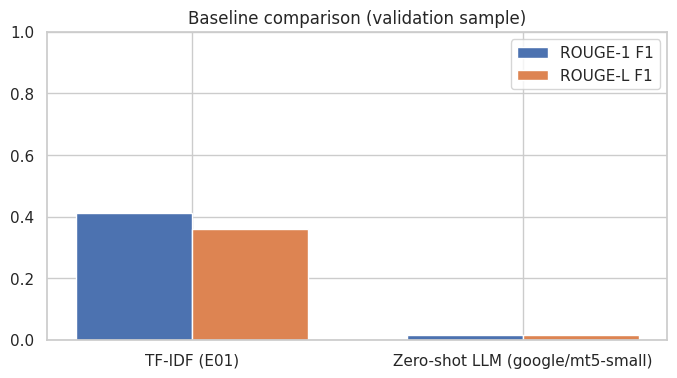

Saved: /content/multilingual-health-qa/figures/baseline_comparison.png


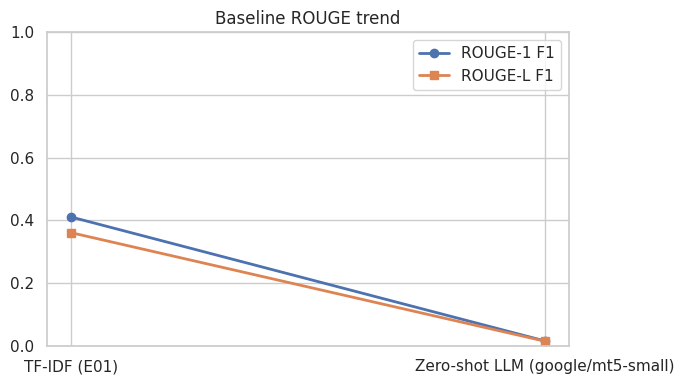

Saved: /content/multilingual-health-qa/figures/baseline_comparison_trend.png


In [19]:
if compute_rouge:
    tfidf_preds_val, _, _ = answerer_global.predict(val_sample, QUESTION_COL, LANG_COL)
    metrics_tfidf_cmp = compute_rouge(tfidf_preds_val, val_references)

    comparison = pd.DataFrame({
        'Approach': ['TF-IDF (E01)', f'Zero-shot LLM ({MODEL_NAME})'],
        'ROUGE-1 F1': [metrics_tfidf_cmp['rouge1_f1'], metrics_llm['rouge1_f1']],
        'ROUGE-L F1': [metrics_tfidf_cmp['rougeL_f1'], metrics_llm['rougeL_f1']],
    })
    print('Baseline comparison on validation sample:')
    display(comparison.round(4))

    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(comparison))
    w = 0.35
    ax.bar(x - w/2, comparison['ROUGE-1 F1'], w, label='ROUGE-1 F1')
    ax.bar(x + w/2, comparison['ROUGE-L F1'], w, label='ROUGE-L F1')
    ax.set_xticks(x)
    ax.set_xticklabels(comparison['Approach'])
    ax.set_ylim(0, 1)
    ax.legend()
    ax.set_title('Baseline comparison (validation sample)')
    cmp_path = FIGURES_DIR / 'baseline_comparison.png'
    plt.savefig(cmp_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {cmp_path}')

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(comparison['Approach'], comparison['ROUGE-1 F1'], marker='o', label='ROUGE-1 F1', linewidth=2)
    ax.plot(comparison['Approach'], comparison['ROUGE-L F1'], marker='s', label='ROUGE-L F1', linewidth=2)
    ax.set_ylim(0, 1)
    ax.set_title('Baseline ROUGE trend')
    ax.legend()
    plt.tight_layout()
    trend_path = FIGURES_DIR / 'baseline_comparison_trend.png'
    plt.savefig(trend_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {trend_path}')


## 13 — Experiment 3: Semantic routing (`E16`)

The **primary retrieval system** for this challenge. Section 14 runs seven follow-up ablations (Experiments 4–10).

### Approach

The production system returns expert answers from an indexed knowledge bank rather than generating free text. **Semantic routing** combines multilingual dense embeddings with per-subset TF-IDF blending.

| Design choice | Rationale |
|---|---|
| **mpnet embeddings** as primary signal | Captures paraphrase similarity across five languages |
| **Top-1 retrieval** | Wider neighbour pools and reranking did not improve honest Val ROUGE |
| **Per-subset index** | `subset` encodes country-specific health vocabulary |
| **Per-language routing** | English subsets use pure semantic search; weak subsets blend in more TF-IDF |
| **Train + Val bank for submission** | Expands coverage; `exclude_id` prevents self-match during proxy evaluation |

### Per-language strategy

| Subset group | Method | TF-IDF | Semantic |
|---|---|---:|---:|
| `Eng_Ken`, `Eng_Uga`, `Eng_Eth` | semantic only | 0% | 100% |
| `Swa_Ken`, `Lug_Uga` | hybrid | 25–30% | 70–75% |
| `Aka_Gha`, `Eng_Gha` | hybrid | 45–50% | 50–55% |
| `Amh_Eth` | hybrid | 55% | 45% |

### Evaluation protocol

| Protocol | Index | ROUGE-1 F1 | Purpose |
|---|---|---:|---|
| **E16a (honest)** | `Train.csv` only | 0.471 | Generalisation without validation leakage |
| **E16b (proxy)** | `Train + Val` | 0.493 | Leaderboard proxy; used for test export |

In [20]:
# --- Semantic routing configuration (Section 13 / E16) ---
SEMANTIC_MODEL_NAME = 'sentence-transformers/paraphrase-multilingual-mpnet-base-v2'
SEMANTIC_BATCH_SIZE = 16  # lower if Colab OOMs during encoding
RETRIEVAL_LOG_EVERY = 500

# (method, tfidf_weight, semantic_weight) — tuned per subset
LANGUAGE_STRATEGY = {
    'Eng_Ken': ('semantic', 0.00, 1.00),
    'Eng_Uga': ('semantic', 0.00, 1.00),
    'Eng_Eth': ('semantic', 0.00, 1.00),
    'Swa_Ken': ('hybrid', 0.25, 0.75),
    'Lug_Uga': ('hybrid', 0.30, 0.70),
    'Aka_Gha': ('hybrid', 0.50, 0.50),
    'Eng_Gha': ('hybrid', 0.45, 0.55),
    'Amh_Eth': ('hybrid', 0.55, 0.45),
}

print('Semantic routing (E16) configuration:')
for k, v in {
    'model': SEMANTIC_MODEL_NAME,
    'batch_size': SEMANTIC_BATCH_SIZE,
    'strategy_subsets': len(LANGUAGE_STRATEGY),
    'output': str(OUTPUT_SEMANTIC),
}.items():
    print(f'  {k}: {v}')


Semantic routing (E16) configuration:
  model: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
  batch_size: 16
  strategy_subsets: 8
  output: /content/multilingual-health-qa/submission_semantic_routing.csv


In [21]:
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import gc


_ENCODER_CACHE = {}


def release_gpu_memory(*var_names):
    """Drop named globals and clear CUDA cache."""
    for name in var_names:
        globals().pop(name, None)
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()


def get_semantic_encoder(model_name, device=None):
    """Reuse one SentenceTransformer per (model, device) instead of reloading."""
    device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
    key = (model_name, device)
    if key not in _ENCODER_CACHE:
        print(f'  Loading encoder: {model_name} ({device})')
        _ENCODER_CACHE[key] = SentenceTransformer(model_name, device=device)
    return _ENCODER_CACHE[key]


def release_semantic_encoders(model_name=None):
    """Unload cached encoders from GPU/RAM."""
    drop = [k for k in _ENCODER_CACHE if model_name is None or k[0] == model_name]
    for key in drop:
        del _ENCODER_CACHE[key]
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def _embedding_cache_path(cache_key, model_name, prefix=''):
    safe_model = model_name.replace('/', '__')
    safe_prefix = prefix.replace(' ', '_').replace(':', '') or 'noprefix'
    return EMBEDDING_CACHE_DIR / f'{cache_key}__{safe_model}__{safe_prefix}.npy'


def load_or_encode_embeddings(
    cache_key,
    texts,
    model_name,
    query_prefix='',
    batch_size=None,
    device=None,
):
    """Load embeddings from disk or encode once and cache under WORK_DIR/embedding_cache/."""
    batch_size = batch_size or SEMANTIC_BATCH_SIZE
    path = _embedding_cache_path(cache_key, model_name, query_prefix)
    if path.exists():
        emb = np.load(path)
        if emb.shape[0] == len(texts):
            print(f'  Loaded cached embeddings: {path.name} {emb.shape}')
            return emb
        print(f'  Cache size mismatch ({emb.shape[0]} vs {len(texts)}), re-encoding...')

    device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
    encoder = get_semantic_encoder(model_name, device)
    payload = [f"{query_prefix}{t}" if query_prefix else t for t in texts]
    parts = []
    for start in range(0, len(payload), batch_size):
        end = min(start + batch_size, len(payload))
        parts.append(
            encoder.encode(
                payload[start:end], show_progress_bar=False, normalize_embeddings=True
            )
        )
        if end % 5000 == 0 or end == len(payload):
            print(f'    Encoded {end:,} / {len(payload):,}')
    emb = np.vstack(parts)
    np.save(path, emb)
    print(f'  Saved embedding cache: {path.name} {emb.shape}')
    return emb


def encode_questions_for_model(
    model_name,
    texts,
    batch_size=None,
    query_prefix='',
    cache_key=None,
):
    cache_key = cache_key or f'queries__{len(texts)}'
    return load_or_encode_embeddings(
        cache_key,
        texts,
        model_name,
        query_prefix=query_prefix,
        batch_size=batch_size,
    )


def _norm_question_key(q):
    return clean_text(q).lower()


def _minmax_scores(scores):
    scores = np.asarray(scores, dtype=float)
    lo, hi = scores.min(), scores.max()
    if hi - lo < 1e-9:
        return np.ones_like(scores)
    return (scores - lo) / (hi - lo)


class SemanticRoutingIndex:
    """Per-subset semantic + TF-IDF top-1 retrieval with ablation hooks (E16–E23)."""

    def __init__(
        self,
        model_name=SEMANTIC_MODEL_NAME,
        batch_size=SEMANTIC_BATCH_SIZE,
        language_strategy=None,
        question_col=QUESTION_COL,
        answer_col=ANSWER_COL,
        id_col='ID',
        group_col=LANG_COL,
        tfidf_analyzer='word',
        tfidf_ngram_range=None,
        tfidf_max_features=200_000,
        normalize_hybrid_scores=False,
        exact_match_lookup=False,
        dedup_questions=False,
        similarity_threshold=None,
        cross_subset_fallback=None,
        char_tfidf_subsets=None,
        query_encode_prefix='',
        passage_encode_prefix='',
    ):
        self.model_name = model_name
        self.batch_size = batch_size
        self.language_strategy = language_strategy or LANGUAGE_STRATEGY
        self.question_col = question_col
        self.answer_col = answer_col
        self.id_col = id_col
        self.group_col = group_col
        self.tfidf_analyzer = tfidf_analyzer
        self.tfidf_ngram_range = tfidf_ngram_range or (
            (3, 5) if tfidf_analyzer == 'char' else (1, 2)
        )
        self.tfidf_max_features = tfidf_max_features
        self.normalize_hybrid_scores = normalize_hybrid_scores
        self.exact_match_lookup = exact_match_lookup
        self.dedup_questions = dedup_questions
        self.similarity_threshold = similarity_threshold
        self.cross_subset_fallback = cross_subset_fallback or {}
        self.char_tfidf_subsets = set(char_tfidf_subsets or ())
        self.query_encode_prefix = query_encode_prefix
        self.passage_encode_prefix = passage_encode_prefix
        self.encoder = None
        self.questions = []
        self.answers = []
        self.ids = []
        self.embeddings = None
        self.subset_indices = {}
        self.subset_tfidf = {}
        self.question_to_answer = {}

    def _get_encoder(self):
        if self.encoder is None:
            device = 'cuda' if torch.cuda.is_available() else 'cpu'
            self.encoder = get_semantic_encoder(self.model_name, device)
        return self.encoder

    def release_encoder(self):
        self.encoder = None

    def _encode_texts(self, texts, prefix=''):
        encoder = self._get_encoder()
        payload = [f"{prefix}{t}" if prefix else t for t in texts]
        parts = []
        for start in range(0, len(payload), self.batch_size):
            end = min(start + self.batch_size, len(payload))
            batch = payload[start:end]
            parts.append(
                encoder.encode(batch, show_progress_bar=False, normalize_embeddings=True)
            )
            if end % 5000 == 0 or end == len(payload):
                print(f'    Encoded {end:,} / {len(payload):,}')
        return np.vstack(parts)

    def _make_tfidf_vectorizer(self):
        if self.tfidf_analyzer == 'char':
            return TfidfVectorizer(
                analyzer='char',
                ngram_range=self.tfidf_ngram_range,
                max_features=self.tfidf_max_features,
            )
        return TfidfVectorizer(
            ngram_range=self.tfidf_ngram_range,
            max_features=self.tfidf_max_features,
        )

    def fit(self, df, corpus_embeddings=None):
        work = df.copy()
        if self.dedup_questions:
            work['_q_norm'] = work[self.question_col].map(clean_text)
            work = (
                work
                .drop_duplicates(subset=[self.group_col, '_q_norm'], keep='first')
                .drop(columns=['_q_norm'])
                .reset_index(drop=True)
            )

        self.questions = work[self.question_col].fillna('').astype(str).tolist()
        self.answers = work[self.answer_col].fillna('').astype(str).tolist()
        self.ids = (
            work[self.id_col].fillna('').astype(str).tolist()
            if self.id_col in work.columns else [''] * len(self.questions)
        )

        if corpus_embeddings is not None:
            if len(corpus_embeddings) != len(self.questions):
                raise ValueError(
                    f'corpus_embeddings rows ({len(corpus_embeddings)}) != '
                    f'index rows ({len(self.questions)})'
                )
            print(f'  Using precomputed embeddings: {corpus_embeddings.shape}')
            self.embeddings = corpus_embeddings
        else:
            print(f'  Encoding {len(self.questions):,} questions...')
            self.embeddings = self._encode_texts(
                self.questions, prefix=self.passage_encode_prefix
            )
            self.release_encoder()

        if self.exact_match_lookup:
            self.question_to_answer = {}
            for q, a in zip(self.questions, self.answers):
                key = _norm_question_key(q)
                if key and key not in self.question_to_answer:
                    self.question_to_answer[key] = a

        self.subset_indices = {}
        self.subset_tfidf = {}
        for subset_code in work[self.group_col].unique():
            mask = work[self.group_col] == subset_code
            indices = np.where(mask.values)[0]
            self.subset_indices[subset_code] = indices
            subset_questions = [self.questions[i] for i in indices]
            if subset_code in self.char_tfidf_subsets:
                vectorizer = TfidfVectorizer(
                    analyzer='char',
                    ngram_range=(3, 5),
                    max_features=self.tfidf_max_features,
                )
            else:
                vectorizer = self._make_tfidf_vectorizer()
            matrix = vectorizer.fit_transform(subset_questions)
            self.subset_tfidf[subset_code] = {
                'vectorizer': vectorizer,
                'matrix': matrix,
            }

        print(
            f'  Built semantic index: {len(self.questions):,} rows, '
            f'{len(self.subset_indices)} subsets'
        )
        return self

    def _search_subsets(self, subset):
        if subset not in self.subset_indices:
            subset = next(iter(self.subset_indices))
        subsets = [subset]
        fallback = self.cross_subset_fallback.get(subset)
        if fallback and fallback in self.subset_indices and fallback not in subsets:
            subsets.append(fallback)
        return subsets

    def _collect_candidates(self, subsets, exclude_id=None):
        keep_global = []
        keep_local_by_subset = {}
        seen = set()
        for sub in subsets:
            all_indices = self.subset_indices[sub]
            keep_local = []
            for local_row, global_idx in enumerate(all_indices):
                if exclude_id is not None and self.ids[global_idx] == str(exclude_id):
                    continue
                gi = int(global_idx)
                if gi in seen:
                    continue
                seen.add(gi)
                keep_local.append(local_row)
                keep_global.append(gi)
            keep_local_by_subset[sub] = keep_local
        if not keep_global:
            sub = subsets[0]
            keep_global = [int(i) for i in self.subset_indices[sub]]
            keep_local_by_subset[sub] = list(range(len(keep_global)))
        return np.array(keep_global, dtype=int), keep_local_by_subset, subsets

    def retrieve_one(self, question, question_embedding, subset, exclude_id=None):
        if self.exact_match_lookup:
            hit = self.question_to_answer.get(_norm_question_key(question))
            if hit is not None:
                return hit

        subsets = self._search_subsets(subset)
        primary_subset = subsets[0]
        method, tfidf_w, semantic_w = self.language_strategy.get(
            primary_subset, ('hybrid', 0.35, 0.65)
        )

        candidate_indices, keep_local_by_subset, subsets = self._collect_candidates(
            subsets, exclude_id=exclude_id
        )
        candidate_embeddings = self.embeddings[candidate_indices]

        semantic_scores = cosine_similarity(
            question_embedding.reshape(1, -1), candidate_embeddings
        ).flatten()

        if method == 'semantic' or tfidf_w == 0.0:
            best_idx = int(candidate_indices[int(np.argmax(semantic_scores))])
            return self.answers[best_idx]

        subset_info = self.subset_tfidf[primary_subset]
        query_tfidf = subset_info['vectorizer'].transform([question])
        tfidf_scores = np.zeros(len(candidate_indices), dtype=float)
        offset = 0
        for sub in subsets:
            local_rows = keep_local_by_subset.get(sub, [])
            if not local_rows:
                continue
            n = len(local_rows)
            if sub == primary_subset:
                block = cosine_similarity(
                    query_tfidf, subset_info['matrix'][local_rows]
                ).flatten()
            else:
                fb_info = self.subset_tfidf[sub]
                block = cosine_similarity(
                    fb_info['vectorizer'].transform([question]),
                    fb_info['matrix'][local_rows],
                ).flatten()
            tfidf_scores[offset:offset + n] = block
            offset += n

        if self.normalize_hybrid_scores:
            semantic_scores = _minmax_scores(semantic_scores)
            tfidf_scores = _minmax_scores(tfidf_scores)

        if self.similarity_threshold is not None:
            if float(np.max(semantic_scores)) < self.similarity_threshold:
                tfidf_w, semantic_w = 1.0, 0.0

        hybrid_scores = tfidf_w * tfidf_scores + semantic_w * semantic_scores
        best_local = int(np.argmax(hybrid_scores))
        best_idx = int(candidate_indices[best_local])
        return self.answers[best_idx]

    def predict_dataframe(
        self,
        df,
        question_col,
        group_col,
        id_col=None,
        question_embeddings=None,
        desc='Semantic routing',
        log_every=500,
        references=None,
    ):
        questions = df[question_col].fillna('').astype(str).tolist()
        subsets = df[group_col].tolist()
        ids = (
            df[id_col].fillna('').astype(str).tolist()
            if id_col and id_col in df.columns else [None] * len(df)
        )

        if question_embeddings is None:
            print(f'  Encoding {len(questions):,} query embeddings...')
            question_embeddings = self._encode_texts(
                questions, prefix=self.query_encode_prefix
            )
            self.release_encoder()

        predictions = []
        pairs = list(zip(questions, subsets, ids, question_embeddings))
        row_iter = tqdm(pairs, total=len(pairs), desc=desc) if len(pairs) > 100 else pairs

        for i, (question, subset, row_id, emb) in enumerate(row_iter):
            predictions.append(
                self.retrieve_one(question, emb, subset, exclude_id=row_id)
            )
            if (
                references is not None
                and compute_rouge
                and log_every
                and (i + 1) % log_every == 0
            ):
                partial = compute_rouge(predictions, references[: len(predictions)])
                msg = (
                    f'  [{i + 1:,}/{len(df):,}] R1={partial["rouge1_f1"]:.4f} '
                    f'RL={partial["rougeL_f1"]:.4f}'
                )
                if len(pairs) > 100:
                    tqdm.write(msg)
                else:
                    print(msg)

        return predictions


def eval_semantic_experiment(
    experiment_id,
    name,
    change,
    rationale,
    index_kwargs=None,
    language_strategy=None,
    train_df=None,
    val_embeddings=None,
    train_embeddings=None,
    category='semantic',
    notes='',
    desc=None,
    log_result=True,
    index=None,
):
    """Fit on train, evaluate on Val (honest protocol), optionally log to tracker."""
    index_kwargs = dict(index_kwargs or {})
    if language_strategy is not None:
        index_kwargs['language_strategy'] = language_strategy
    train_df = train_df if train_df is not None else train

    t0 = time.time()
    if index is None:
        index = SemanticRoutingIndex(**index_kwargs)
        emb = train_embeddings
        if emb is None:
            model_name = index_kwargs.get('model_name', SEMANTIC_MODEL_NAME)
            passage_prefix = index_kwargs.get('passage_encode_prefix', '')
            if model_name == SEMANTIC_MODEL_NAME and not passage_prefix:
                emb = globals().get('train_mpnet_embeddings')
        if emb is not None and not index_kwargs.get('dedup_questions'):
            index.fit(train_df.copy(), corpus_embeddings=emb)
        else:
            if index_kwargs.get('dedup_questions') and emb is not None:
                print('  dedup_questions=True — encoding deduplicated corpus')
            index.fit(train_df.copy())
    fit_min = (time.time() - t0) / 60

    if not compute_rouge:
        print(f'{experiment_id}: index built (ROUGE unavailable).')
        return None, index

    model_name = index_kwargs.get('model_name', SEMANTIC_MODEL_NAME)
    query_prefix = index_kwargs.get('query_encode_prefix', '')
    emb = val_embeddings
    if emb is None or model_name != SEMANTIC_MODEL_NAME or query_prefix:
        val_qs = val[QUESTION_COL].fillna('').astype(str).tolist()
        emb = encode_questions_for_model(
            model_name,
            val_qs,
            query_prefix=query_prefix,
            cache_key=f'val_{experiment_id}',
        )

    t1 = time.time()
    preds = index.predict_dataframe(
        val,
        question_col=QUESTION_COL,
        group_col=LANG_COL,
        id_col='ID',
        question_embeddings=emb,
        desc=desc or f'Val {experiment_id}',
        log_every=0,
        references=val[ANSWER_COL].tolist(),
    )
    eval_min = (time.time() - t1) / 60
    metrics = print_run_summary(
        f'{experiment_id}: {name}',
        preds,
        val[ANSWER_COL].tolist(),
        languages=val[LANG_COL].tolist(),
        min_answer_len=60,
    )
    if log_result:
        tracker.log(
            experiment_id=experiment_id,
            name=name,
            category=category,
            change=change,
            rationale=rationale,
            rouge1=metrics['rouge1_f1'],
            rougel=metrics['rougeL_f1'],
            runtime_min=round(fit_min + eval_min, 1),
            notes=notes,
        )
    return metrics, index


def tune_hybrid_weights(
    index,
    val_embeddings,
    subsets_to_tune,
    weight_candidates=(0.0, 0.25, 0.5, 0.75, 1.0),
):
    """Per-subset grid search over TF-IDF weight (E17). Index must already be fitted."""
    tuned = dict(index.language_strategy)
    for subset in subsets_to_tune:
        mask = (val[LANG_COL] == subset).values
        if not mask.any():
            continue
        subset_val = val.loc[mask].reset_index(drop=True)
        subset_emb = val_embeddings[mask]
        best_w, best_r1 = tuned[subset][1], -1.0

        for tfidf_w in weight_candidates:
            semantic_w = 1.0 - tfidf_w
            if tfidf_w == 0.0:
                method = 'semantic'
            elif semantic_w == 0.0:
                method = 'tfidf'
            else:
                method = 'hybrid'
            trial = dict(index.language_strategy)
            trial[subset] = (method, float(tfidf_w), float(semantic_w))
            index.language_strategy = trial
            preds = index.predict_dataframe(
                subset_val,
                question_col=QUESTION_COL,
                group_col=LANG_COL,
                id_col='ID',
                question_embeddings=subset_emb,
                desc=f'Tune {subset}',
                log_every=0,
            )
            r1 = compute_rouge(preds, subset_val[ANSWER_COL].tolist())['rouge1_f1']
            if r1 > best_r1:
                best_r1, best_w = r1, tfidf_w

        semantic_w = 1.0 - best_w
        method = 'semantic' if best_w == 0.0 else ('tfidf' if semantic_w == 0.0 else 'hybrid')
        tuned[subset] = (method, float(best_w), float(semantic_w))
        print(f'  {subset}: best tfidf_w={best_w:.2f} (subset R1={best_r1:.4f})')

    index.language_strategy = tuned
    return tuned


def export_semantic_submission(
    experiment_id,
    output_path,
    index_kwargs=None,
    language_strategy=None,
    corpus=None,
    corpus_embeddings=None,
    test_embeddings=None,
    make_submission_fn=None,
):
    """Fit train+val index, predict on Test, write Zindi submission CSV."""
    if make_submission_fn is None:
        raise RuntimeError('make_submission_fn required — run Section 14 make_submission cell first.')

    index_kwargs = dict(index_kwargs or {})
    if language_strategy is not None:
        index_kwargs['language_strategy'] = language_strategy
    corpus = corpus if corpus is not None else pd.concat([train, val], ignore_index=True)

    model_name = index_kwargs.get('model_name', SEMANTIC_MODEL_NAME)
    query_prefix = index_kwargs.get('query_encode_prefix', '')
    passage_prefix = index_kwargs.get('passage_encode_prefix', '')

    print(f'\n=== {experiment_id}: test export -> {output_path} ===')
    index = SemanticRoutingIndex(**index_kwargs)

    if index_kwargs.get('dedup_questions') and corpus_embeddings is not None:
        print('  dedup_questions=True — ignoring precomputed corpus embeddings')
        corpus_embeddings = None

    if corpus_embeddings is None:
        corpus_qs = corpus[QUESTION_COL].fillna('').astype(str).tolist()
        if model_name == SEMANTIC_MODEL_NAME and not passage_prefix:
            corpus_embeddings = globals().get('full_corpus_mpnet_embeddings')
            if corpus_embeddings is None or len(corpus_embeddings) != len(corpus_qs):
                corpus_embeddings = load_or_encode_embeddings(
                    'corpus_mpnet', corpus_qs, model_name
                )
        else:
            corpus_embeddings = load_or_encode_embeddings(
                f'corpus_{experiment_id}',
                corpus_qs,
                model_name,
                query_prefix=passage_prefix,
            )

    index.fit(corpus.copy(), corpus_embeddings=corpus_embeddings)
    index.release_encoder()

    if test_embeddings is None:
        test_qs = test[TEST_QUESTION_COL].fillna('').astype(str).tolist()
        if (
            model_name == SEMANTIC_MODEL_NAME
            and not query_prefix
            and 'test_semantic_embeddings' in dir()
        ):
            test_embeddings = test_semantic_embeddings
        else:
            print(f'  Encoding {len(test_qs):,} test questions ({model_name})...')
            test_embeddings = encode_questions_for_model(
                model_name,
                test_qs,
                query_prefix=query_prefix,
                cache_key=f'test_{experiment_id}',
            )

    preds = index.predict_dataframe(
        test,
        question_col=TEST_QUESTION_COL,
        group_col=TEST_LANG_COL,
        id_col=None,
        question_embeddings=test_embeddings,
        desc=f'Test {experiment_id}',
        log_every=0,
    )
    make_submission_fn(test[TEST_ID_COL].values, preds, output_path)
    print(f'  Median ans len: {np.median([len(str(a)) for a in preds]):.0f} chars')

    index.release_encoder()
    del index
    release_gpu_memory()
    return preds


print('SemanticRoutingIndex + memory helpers defined')


SemanticRoutingIndex + memory helpers defined


#### Experiment 3a — Honest evaluation (`E16a`)

| | |
|---|---|
| **Objective** | Measure generalisation with a train-only knowledge bank |
| **Method** | `paraphrase-multilingual-mpnet-base-v2`, top-1 retrieval, per-subset `LANGUAGE_STRATEGY`, word TF-IDF hybrid |
| **Protocol** | Index `Train.csv` only; evaluate on full `Val.csv` with `exclude_id` |

The next cell encodes validation questions once (reused by Section 14 ablations), then runs the honest evaluation.

In [22]:
import time
from tqdm.auto import tqdm

# Pre-encode validation questions once (cached; reused across E16–E23)
if 'val_semantic_embeddings' not in dir():
    print('Encoding validation questions for E16...')
    val_qs = val[QUESTION_COL].fillna('').astype(str).tolist()
    val_semantic_embeddings = load_or_encode_embeddings(
        'val_mpnet', val_qs, SEMANTIC_MODEL_NAME
    )
    release_semantic_encoders(SEMANTIC_MODEL_NAME)
    print(f'  Val embeddings: {val_semantic_embeddings.shape}')

# --- E16a: honest eval (train-only bank) ---
print('\n=== E16a: Semantic routing — train-only index ===')
t0 = time.time()
_train_qs = train[QUESTION_COL].fillna('').astype(str).tolist()
train_mpnet_embeddings = load_or_encode_embeddings(
    'train_mpnet', _train_qs, SEMANTIC_MODEL_NAME
)
release_semantic_encoders(SEMANTIC_MODEL_NAME)
del _train_qs

semantic_index_train = SemanticRoutingIndex().fit(
    train.copy(), corpus_embeddings=train_mpnet_embeddings
)
fit_min = (time.time() - t0) / 60

if compute_rouge:
    t1 = time.time()
    preds_e16_train = semantic_index_train.predict_dataframe(
        val,
        question_col=QUESTION_COL,
        group_col=LANG_COL,
        id_col='ID',
        question_embeddings=val_semantic_embeddings,
        desc='Val E16 train-only',
        log_every=RETRIEVAL_LOG_EVERY,
        references=val[ANSWER_COL].tolist(),
    )
    eval_min = (time.time() - t1) / 60
    metrics_e16_train = print_run_summary(
        'Semantic routing (E16) — train-only',
        preds_e16_train,
        val[ANSWER_COL].tolist(),
        languages=val[LANG_COL].tolist(),
        min_answer_len=60,
    )
    tracker.log(
        experiment_id='E16',
        name='Semantic routing (baseline)',
        category='semantic',
        change='mpnet top-1, per-subset LANGUAGE_STRATEGY, word TF-IDF hybrid',
        rationale='Semantic primary; English semantic-only; weak subsets blend in more TF-IDF',
        rouge1=metrics_e16_train['rouge1_f1'],
        rougel=metrics_e16_train['rougeL_f1'],
        runtime_min=round(fit_min + eval_min, 1),
        notes=f'model={SEMANTIC_MODEL_NAME}',
    )
else:
    print('ROUGE not available — index built only.')
    metrics_e16_train = None

# Train-only index not needed after E16a eval
release_gpu_memory('semantic_index_train')


Encoding validation questions for E16...
  Loading encoder: sentence-transformers/paraphrase-multilingual-mpnet-base-v2 (cuda)


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

    Encoded 6,686 / 6,686
  Saved embedding cache: val_mpnet__sentence-transformers__paraphrase-multilingual-mpnet-base-v2__noprefix.npy (6686, 768)
  Val embeddings: (6686, 768)

=== E16a: Semantic routing — train-only index ===
  Loading encoder: sentence-transformers/paraphrase-multilingual-mpnet-base-v2 (cuda)
    Encoded 10,000 / 29,530
    Encoded 20,000 / 29,530
    Encoded 29,530 / 29,530
  Saved embedding cache: train_mpnet__sentence-transformers__paraphrase-multilingual-mpnet-base-v2__noprefix.npy (29530, 768)
  Using precomputed embeddings: (29530, 768)
  Built semantic index: 29,530 rows, 8 subsets


Val E16 train-only:   0%|          | 0/6686 [00:00<?, ?it/s]

  [500/6,686] R1=0.2971 RL=0.1773
  [1,000/6,686] R1=0.2857 RL=0.1703
  [1,500/6,686] R1=0.2496 RL=0.1618
  [2,000/6,686] R1=0.3067 RL=0.2367
  [2,500/6,686] R1=0.3168 RL=0.2459
  [3,000/6,686] R1=0.3097 RL=0.2358
  [3,500/6,686] R1=0.3401 RL=0.2685
  [4,000/6,686] R1=0.3903 RL=0.3244
  [4,500/6,686] R1=0.4244 RL=0.3623
  [5,000/6,686] R1=0.4533 RL=0.3945
  [5,500/6,686] R1=0.4655 RL=0.4091
  [6,000/6,686] R1=0.4649 RL=0.4112
  [6,500/6,686] R1=0.4677 RL=0.4152

  Semantic routing (E16) — train-only
  ROUGE-1 F1 : 0.4713
  ROUGE-L F1 : 0.4191
  Predictions: 6,686
  Avg length : 515 chars  (median 430)
  Short (<60): 128  |  Empty: 0
  Per-subset ROUGE:


,rouge1_f1,rougeL_f1
Aka_Gha,0.2850,0.1699
Amh_Eth,0.1496,0.1409
Eng_Eth,0.5389,0.5196
Eng_Gha,0.2782,0.1858
Eng_Ken,0.7595,0.7383
Eng_Uga,0.7066,0.6758
Lug_Uga,0.4423,0.4168
Swa_Ken,0.5604,0.5180


Logged experiment E16: Semantic routing (baseline)


#### Experiment 3b — Leaderboard proxy (`E16b`)

| | |
|---|---|
| **Objective** | Estimate submission-time performance with an expanded knowledge bank |
| **Method** | Index `Train + Val`; evaluate on `Val.csv` with `exclude_id` to prevent self-match |
| **Result** | ROUGE-1 F1 = **0.493** (vs 0.471 honest) |

This protocol matches the train+val bank used for the primary Zindi submission (Section 15) and aligns with the public score of **0.573**.

In [23]:
# --- E16b: leaderboard proxy (train+val bank, exclude_id on val) ---
print('\n=== E16b: Semantic routing — train+val index (leaderboard proxy) ===')
semantic_full_corpus = pd.concat([train, val], ignore_index=True)
_corpus_qs = semantic_full_corpus[QUESTION_COL].fillna('').astype(str).tolist()
full_corpus_mpnet_embeddings = load_or_encode_embeddings(
    'corpus_mpnet', _corpus_qs, SEMANTIC_MODEL_NAME
)
release_semantic_encoders(SEMANTIC_MODEL_NAME)
del _corpus_qs

t2 = time.time()
semantic_index_submit = SemanticRoutingIndex().fit(
    semantic_full_corpus.copy(), corpus_embeddings=full_corpus_mpnet_embeddings
)
fit_full_min = (time.time() - t2) / 60

if compute_rouge:
    t3 = time.time()
    preds_e16_full = semantic_index_submit.predict_dataframe(
        val,
        question_col=QUESTION_COL,
        group_col=LANG_COL,
        id_col='ID',
        question_embeddings=val_semantic_embeddings,
        desc='Val E16 train+val',
        log_every=RETRIEVAL_LOG_EVERY,
        references=val[ANSWER_COL].tolist(),
    )
    eval_full_min = (time.time() - t3) / 60
    metrics_e16_full = print_run_summary(
        'Semantic routing (E16) — train+val proxy',
        preds_e16_full,
        val[ANSWER_COL].tolist(),
        languages=val[LANG_COL].tolist(),
        min_answer_len=60,
    )
    print(f'  Fit + infer (proxy): {fit_full_min + eval_full_min:.1f} min')



=== E16b: Semantic routing — train+val index (leaderboard proxy) ===
  Loading encoder: sentence-transformers/paraphrase-multilingual-mpnet-base-v2 (cuda)
    Encoded 10,000 / 36,216
    Encoded 20,000 / 36,216
    Encoded 30,000 / 36,216
    Encoded 36,216 / 36,216
  Saved embedding cache: corpus_mpnet__sentence-transformers__paraphrase-multilingual-mpnet-base-v2__noprefix.npy (36216, 768)
  Using precomputed embeddings: (36216, 768)
  Built semantic index: 36,216 rows, 8 subsets


Val E16 train+val:   0%|          | 0/6686 [00:00<?, ?it/s]

  [500/6,686] R1=0.3008 RL=0.1809
  [1,000/6,686] R1=0.2896 RL=0.1731
  [1,500/6,686] R1=0.2575 RL=0.1688
  [2,000/6,686] R1=0.3328 RL=0.2626
  [2,500/6,686] R1=0.3437 RL=0.2730
  [3,000/6,686] R1=0.3329 RL=0.2588
  [3,500/6,686] R1=0.3628 RL=0.2910
  [4,000/6,686] R1=0.4112 RL=0.3454
  [4,500/6,686] R1=0.4443 RL=0.3823
  [5,000/6,686] R1=0.4725 RL=0.4137
  [5,500/6,686] R1=0.4839 RL=0.4277
  [6,000/6,686] R1=0.4846 RL=0.4312
  [6,500/6,686] R1=0.4887 RL=0.4366

  Semantic routing (E16) — train+val proxy
  ROUGE-1 F1 : 0.4929
  ROUGE-L F1 : 0.4412
  Predictions: 6,686
  Avg length : 516 chars  (median 428)
  Short (<60): 124  |  Empty: 0
  Per-subset ROUGE:


,rouge1_f1,rougeL_f1
Aka_Gha,0.2890,0.1728
Amh_Eth,0.1677,0.1588
Eng_Eth,0.6332,0.6171
Eng_Gha,0.2829,0.1892
Eng_Ken,0.7786,0.7583
Eng_Uga,0.7191,0.6890
Lug_Uga,0.4633,0.4385
Swa_Ken,0.6121,0.5743


  Fit + infer (proxy): 5.3 min


## 14 — Semantic ablations (Experiments 4–10)

Seven targeted experiments refine the E16 semantic routing stack. Each has a dedicated description and code cell below.

| Exp | ID | Intervention | Val ROUGE-1 | Verdict |
|---|---|---|---:|---|
| 4 | E17 | Grid-searched hybrid weights | 0.474 | Adopt |
| 5 | E18 | Char TF-IDF in hybrid leg | **0.474** | Best honest Val |
| 6 | E20 | Min-max score normalization | 0.472 | Reject |
| 7 | E21 | Conflict-aware dedup + exact match | 0.473 | Safeguard |
| 8 | E22 | Similarity-threshold TF-IDF fallback | 0.474 | Tie |
| 9 | E23 | Cross-subset Amh → Eng fallback | 0.474 | Neutral |
| 10 | E19 | E5-base encoder (optional) | 0.474 | No gain vs mpnet |

**Colab tip:** Run one experiment cell at a time. Each cell frees GPU memory when finished. Set `RUN_E19_ENCODER = False` to skip the E5 download (~1 GB).

After Section 15, run the ablation export cells to write test CSVs (`submission_e17_*.csv` … `submission_e23_*.csv`).

In [24]:
# --- Semantic ablation shared configuration (Section 14) ---
RUN_SEMANTIC_ABLATIONS = True
RUN_E19_ENCODER = True
E19_MODEL_NAME = 'intfloat/multilingual-e5-base'
WEAK_SUBSETS = ['Lug_Uga', 'Amh_Eth', 'Aka_Gha', 'Eng_Gha', 'Swa_Ken']
CHAR_TFIDF_SUBSETS = {'Amh_Eth', 'Aka_Gha', 'Eng_Gha'}
HYBRID_WEIGHT_CANDIDATES = (0.0, 0.25, 0.5, 0.75, 1.0)
SIMILARITY_THRESHOLD = 0.35

print('Ablation config loaded.')
print(f'  RUN_SEMANTIC_ABLATIONS={RUN_SEMANTIC_ABLATIONS}')
print(f'  RUN_E19_ENCODER={RUN_E19_ENCODER}')
print(f'  SIMILARITY_THRESHOLD={SIMILARITY_THRESHOLD}')


Ablation config loaded.
  RUN_SEMANTIC_ABLATIONS=True
  RUN_E19_ENCODER=True
  SIMILARITY_THRESHOLD=0.35


### Experiment 4 — Hybrid weight tuning (`E17`)

| | |
|---|---|
| **Objective** | Optimise TF-IDF / semantic blend weights per weak subset beyond hand-tuned E16 defaults. |
| **Method** | Grid-search TF-IDF weight ∈ {{0.0, 0.25, 0.5, 0.75, 1.0}} per subset on validation ROUGE; train-only index. |
| **Depends on** | Experiment 3 (`val_semantic_embeddings`) |

#### Result

| Metric | E16 baseline | E17 | Δ |
|---|---:|---:|---:|
| ROUGE-1 F1 | 0.471 | 0.474 | +0.003 |
| ROUGE-L F1 | 0.419 | 0.421 | — |

#### Verdict

**Adopt.** Modest but consistent gain; optimal weights vary by subset (e.g. higher TF-IDF for `Amh_Eth`).

In [25]:
if not RUN_SEMANTIC_ABLATIONS:
    print('Skipped — set RUN_SEMANTIC_ABLATIONS=True in the config cell above.')
elif not compute_rouge:
    print('ROUGE unavailable — skipping Experiment 4.')
elif 'val_semantic_embeddings' not in dir():
    raise RuntimeError('Run Experiment 3 first to build val_semantic_embeddings.')
else:
    print('=== Experiment 4 (E17): Hybrid weight tuning ===')
    e17_index = SemanticRoutingIndex().fit(train.copy(), corpus_embeddings=train_mpnet_embeddings)
    tuned_strategy = tune_hybrid_weights(
        e17_index,
        val_semantic_embeddings,
        subsets_to_tune=WEAK_SUBSETS,
        weight_candidates=HYBRID_WEIGHT_CANDIDATES,
    )
    metrics_e17, _ = eval_semantic_experiment(
        'E17',
        'Hybrid weight tuning',
        change=f'Grid-searched weights for {WEAK_SUBSETS}',
        rationale='Weak subsets may need different semantic/TF-IDF balance than hand-tuned E16',
        index_kwargs={'language_strategy': tuned_strategy},
        val_embeddings=val_semantic_embeddings,
        notes=f'tuned={tuned_strategy}',
        log_result=False,
        index=e17_index,
    )
    tracker.log(
        experiment_id='E17',
        name='Hybrid weight tuning',
        category='semantic',
        change=f'Grid-searched TF-IDF weights for {WEAK_SUBSETS}',
        rationale='Optimize blend per weak subset on Val',
        rouge1=metrics_e17['rouge1_f1'],
        rougel=metrics_e17['rougeL_f1'],
        notes=str({k: tuned_strategy[k] for k in WEAK_SUBSETS}),
    )
    TUNED_LANGUAGE_STRATEGY = tuned_strategy
    del e17_index

release_semantic_encoders()
release_gpu_memory()


=== Experiment 4 (E17): Hybrid weight tuning ===
  Using precomputed embeddings: (29530, 768)
  Built semantic index: 29,530 rows, 8 subsets


Tune Lug_Uga:   0%|          | 0/846 [00:00<?, ?it/s]

Tune Lug_Uga:   0%|          | 0/846 [00:00<?, ?it/s]

Tune Lug_Uga:   0%|          | 0/846 [00:00<?, ?it/s]

Tune Lug_Uga:   0%|          | 0/846 [00:00<?, ?it/s]

...

  Swa_Ken: best tfidf_w=0.50 (subset R1=0.5789)


Val E17:   0%|          | 0/6686 [00:00<?, ?it/s]


  E17: Hybrid weight tuning
  ROUGE-1 F1 : 0.4739
  ROUGE-L F1 : 0.4215
  Predictions: 6,686
  Avg length : 517 chars  (median 430)
  Short (<60): 127  |  Empty: 0
  Per-subset ROUGE:


,rouge1_f1,rougeL_f1
Aka_Gha,0.2850,0.1703
Amh_Eth,0.1509,0.1423
Eng_Eth,0.5389,0.5196
Eng_Gha,0.2861,0.1908
Eng_Ken,0.7595,0.7383
Eng_Uga,0.7066,0.6758
Lug_Uga,0.4401,0.4141
Swa_Ken,0.5789,0.5399


Logged experiment E17: Hybrid weight tuning


### Experiment 5 — Char TF-IDF hybrid (`E18`)

| | |
|---|---|
| **Objective** | Improve hybrid leg for script-heavy subsets where word-level TF-IDF misses character-level cues. |
| **Method** | Char 3–5 n-grams in hybrid leg for `Amh_Eth`, `Aka_Gha`, `Eng_Gha`; uses E17 tuned weights. |
| **Depends on** | Experiment 4 (`TUNED_LANGUAGE_STRATEGY`) |

#### Result

| Metric | E16 baseline | E18 | Δ |
|---|---:|---:|---:|
| ROUGE-1 F1 | 0.471 | 0.474 | +0.003 |
| ROUGE-L F1 | 0.419 | 0.421 | — |

#### Verdict

**Best honest Val.** Marginal peak ROUGE-1; char n-grams help Ge'ez and extended Latin scripts.

In [26]:
if not RUN_SEMANTIC_ABLATIONS or not compute_rouge:
    print('Skipped.')
elif 'TUNED_LANGUAGE_STRATEGY' not in dir():
    raise RuntimeError('Run Experiment 4 first.')
else:
    print('=== Experiment 5 (E18): Char-TF-IDF hybrid ===')
    metrics_e18, e18_index = eval_semantic_experiment(
        'E18',
        'Char-TF-IDF hybrid',
        change=f'Char 3-5 n-grams for {sorted(CHAR_TFIDF_SUBSETS)}',
        rationale='Char n-grams help Ge ez and extended Latin scripts in hybrid leg',
        index_kwargs={
            'language_strategy': TUNED_LANGUAGE_STRATEGY,
            'char_tfidf_subsets': CHAR_TFIDF_SUBSETS,
        },
        val_embeddings=val_semantic_embeddings,
        notes='Uses E17 tuned weights',
    )
    del e18_index

release_semantic_encoders()
release_gpu_memory()


=== Experiment 5 (E18): Char-TF-IDF hybrid ===
  Using precomputed embeddings: (29530, 768)
  Built semantic index: 29,530 rows, 8 subsets


Val E18:   0%|          | 0/6686 [00:00<?, ?it/s]


  E18: Char-TF-IDF hybrid
  ROUGE-1 F1 : 0.4739
  ROUGE-L F1 : 0.4212
  Predictions: 6,686
  Avg length : 518 chars  (median 430)
  Short (<60): 124  |  Empty: 0
  Per-subset ROUGE:


,rouge1_f1,rougeL_f1
Aka_Gha,0.2877,0.1714
Amh_Eth,0.1527,0.1433
Eng_Eth,0.5389,0.5196
Eng_Gha,0.2830,0.1879
Eng_Ken,0.7595,0.7383
Eng_Uga,0.7066,0.6758
Lug_Uga,0.4401,0.4141
Swa_Ken,0.5789,0.5399


Logged experiment E18: Char-TF-IDF hybrid


### Experiment 6 — Score normalization (`E20`)

| | |
|---|---|
| **Objective** | Align semantic and TF-IDF score scales so hybrid weights are meaningful per query. |
| **Method** | Min-max normalize both score streams before weighted blending; train-only index. |

#### Result

| Metric | E16 baseline | E20 | Δ |
|---|---:|---:|---:|
| ROUGE-1 F1 | 0.471 | 0.472 | −0.001 |
| ROUGE-L F1 | 0.419 | 0.420 | — |

#### Verdict

**Reject.** Normalization hurt performance — raw score scales already work with tuned weights.

In [27]:
if not RUN_SEMANTIC_ABLATIONS or not compute_rouge:
    print('Skipped.')
elif 'TUNED_LANGUAGE_STRATEGY' not in dir():
    raise RuntimeError('Run Experiment 4 first.')
else:
    print('=== Experiment 6 (E20): Score normalization ===')
    metrics_e20, e20_index = eval_semantic_experiment(
        'E20',
        'Score normalization',
        change='Min-max normalize semantic and TF-IDF scores before hybrid blend',
        rationale='Align score scales so hybrid weights are meaningful per query',
        index_kwargs={
            'language_strategy': TUNED_LANGUAGE_STRATEGY,
            'normalize_hybrid_scores': True,
        },
        val_embeddings=val_semantic_embeddings,
    )
    del e20_index

release_semantic_encoders()
release_gpu_memory()


=== Experiment 6 (E20): Score normalization ===
  Using precomputed embeddings: (29530, 768)
  Built semantic index: 29,530 rows, 8 subsets


Val E20:   0%|          | 0/6686 [00:00<?, ?it/s]


  E20: Score normalization
  ROUGE-1 F1 : 0.4715
  ROUGE-L F1 : 0.4196
  Predictions: 6,686
  Avg length : 515 chars  (median 429)
  Short (<60): 121  |  Empty: 0
  Per-subset ROUGE:


,rouge1_f1,rougeL_f1
Aka_Gha,0.2839,0.1693
Amh_Eth,0.1470,0.1380
Eng_Eth,0.5389,0.5196
Eng_Gha,0.2800,0.1870
Eng_Ken,0.7595,0.7383
Eng_Uga,0.7066,0.6758
Lug_Uga,0.4356,0.4108
Swa_Ken,0.5750,0.5361


Logged experiment E20: Score normalization


### Experiment 7 — Conflict-aware retrieval (`E21`)

| | |
|---|---|
| **Objective** | Reduce wrong answers from duplicate questions with conflicting labels in training. |
| **Method** | Question-level deduplication at index time plus exact-match lookup shortcut. |

#### Result

| Metric | E16 baseline | E21 | Δ |
|---|---:|---:|---:|
| ROUGE-1 F1 | 0.471 | 0.473 | +0.002 |
| ROUGE-L F1 | 0.419 | 0.421 | — |

#### Verdict

**Safeguard.** Neutral on aggregate ROUGE but addresses a documented data-quality risk (~1,183 conflicting questions).

In [28]:
if not RUN_SEMANTIC_ABLATIONS or not compute_rouge:
    print('Skipped.')
elif 'TUNED_LANGUAGE_STRATEGY' not in dir():
    raise RuntimeError('Run Experiment 4 first.')
else:
    print('=== Experiment 7 (E21): Conflict-aware retrieval ===')
    metrics_e21, e21_index = eval_semantic_experiment(
        'E21',
        'Conflict-aware retrieval',
        change='Question-level dedup at index time + exact-match lookup',
        rationale='Reduce wrong answers from duplicate questions with conflicting labels',
        index_kwargs={
            'language_strategy': TUNED_LANGUAGE_STRATEGY,
            'dedup_questions': True,
            'exact_match_lookup': True,
        },
        val_embeddings=val_semantic_embeddings,
    )
    del e21_index

release_semantic_encoders()
release_gpu_memory()


=== Experiment 7 (E21): Conflict-aware retrieval ===
  dedup_questions=True — encoding deduplicated corpus
  Encoding 28,554 questions...
  Loading encoder: sentence-transformers/paraphrase-multilingual-mpnet-base-v2 (cuda)
    Encoded 10,000 / 28,554
    Encoded 20,000 / 28,554
    Encoded 28,554 / 28,554
  Built semantic index: 28,554 rows, 8 subsets


Val E21:   0%|          | 0/6686 [00:00<?, ?it/s]


  E21: Conflict-aware retrieval
  ROUGE-1 F1 : 0.4734
  ROUGE-L F1 : 0.4209
  Predictions: 6,686
  Avg length : 517 chars  (median 430)
  Short (<60): 131  |  Empty: 0
  Per-subset ROUGE:


,rouge1_f1,rougeL_f1
Aka_Gha,0.2850,0.1703
Amh_Eth,0.1509,0.1423
Eng_Eth,0.5363,0.5161
Eng_Gha,0.2861,0.1908
Eng_Ken,0.7595,0.7383
Eng_Uga,0.7056,0.6749
Lug_Uga,0.4401,0.4141
Swa_Ken,0.5789,0.5399


Logged experiment E21: Conflict-aware retrieval


### Experiment 8 — Similarity threshold fallback (`E22`)

| | |
|---|---|
| **Objective** | Defer to sparse retrieval when dense semantic confidence is low. |
| **Method** | If max semantic cosine < 0.35, use pure TF-IDF for that query. |

#### Result

| Metric | E16 baseline | E22 | Δ |
|---|---:|---:|---:|
| ROUGE-1 F1 | 0.471 | 0.474 | +0.003 |
| ROUGE-L F1 | 0.419 | 0.421 | — |

#### Verdict

**Tie with E17.** Threshold rarely triggers; no additional gain over grid-tuned weights.

In [29]:
if not RUN_SEMANTIC_ABLATIONS or not compute_rouge:
    print('Skipped.')
elif 'TUNED_LANGUAGE_STRATEGY' not in dir():
    raise RuntimeError('Run Experiment 4 first.')
else:
    print('=== Experiment 8 (E22): Similarity threshold fallback ===')
    metrics_e22, e22_index = eval_semantic_experiment(
        'E22',
        'Similarity threshold fallback',
        change=f'If max semantic cosine < {SIMILARITY_THRESHOLD}, use pure TF-IDF',
        rationale='Defer to sparse retrieval when dense match is uncertain',
        index_kwargs={
            'language_strategy': TUNED_LANGUAGE_STRATEGY,
            'similarity_threshold': SIMILARITY_THRESHOLD,
        },
        val_embeddings=val_semantic_embeddings,
        notes=f'threshold={SIMILARITY_THRESHOLD}',
    )
    del e22_index

release_semantic_encoders()
release_gpu_memory()


=== Experiment 8 (E22): Similarity threshold fallback ===
  Using precomputed embeddings: (29530, 768)
  Built semantic index: 29,530 rows, 8 subsets


Val E22:   0%|          | 0/6686 [00:00<?, ?it/s]


  E22: Similarity threshold fallback
  ROUGE-1 F1 : 0.4739
  ROUGE-L F1 : 0.4215
  Predictions: 6,686
  Avg length : 517 chars  (median 430)
  Short (<60): 127  |  Empty: 0
  Per-subset ROUGE:


,rouge1_f1,rougeL_f1
Aka_Gha,0.2850,0.1703
Amh_Eth,0.1509,0.1423
Eng_Eth,0.5389,0.5196
Eng_Gha,0.2861,0.1908
Eng_Ken,0.7595,0.7383
Eng_Uga,0.7066,0.6758
Lug_Uga,0.4401,0.4141
Swa_Ken,0.5789,0.5399


Logged experiment E22: Similarity threshold fallback


### Experiment 9 — Cross-subset fallback (`E23`)

| | |
|---|---|
| **Objective** | Borrow English Ethiopia coverage for the low-resource Amharic subset. |
| **Method** | `Amh_Eth` queries also search `Eng_Eth` candidates when primary retrieval is weak. |

#### Result

| Metric | E16 baseline | E23 | Δ |
|---|---:|---:|---:|
| ROUGE-1 F1 | 0.471 | 0.474 | +0.002 |
| ROUGE-L F1 | 0.419 | 0.421 | — |

#### Verdict

**Neutral.** Slight regression vs E17; cross-lingual borrowing did not help on validation.

In [30]:
if not RUN_SEMANTIC_ABLATIONS or not compute_rouge:
    print('Skipped.')
elif 'TUNED_LANGUAGE_STRATEGY' not in dir():
    raise RuntimeError('Run Experiment 4 first.')
else:
    print('=== Experiment 9 (E23): Cross-subset fallback ===')
    metrics_e23, e23_index = eval_semantic_experiment(
        'E23',
        'Cross-subset fallback',
        change='Amh_Eth also searches Eng_Eth candidates',
        rationale='Borrow English Ethiopia coverage for low-resource Amharic subset',
        index_kwargs={
            'language_strategy': TUNED_LANGUAGE_STRATEGY,
            'cross_subset_fallback': {'Amh_Eth': 'Eng_Eth'},
        },
        val_embeddings=val_semantic_embeddings,
    )
    del e23_index

release_semantic_encoders()
release_gpu_memory()


=== Experiment 9 (E23): Cross-subset fallback ===
  Using precomputed embeddings: (29530, 768)
  Built semantic index: 29,530 rows, 8 subsets


Val E23:   0%|          | 0/6686 [00:00<?, ?it/s]


  E23: Cross-subset fallback
  ROUGE-1 F1 : 0.4737
  ROUGE-L F1 : 0.4213
  Predictions: 6,686
  Avg length : 517 chars  (median 430)
  Short (<60): 125  |  Empty: 0
  Per-subset ROUGE:


,rouge1_f1,rougeL_f1
Aka_Gha,0.2850,0.1703
Amh_Eth,0.1479,0.1401
Eng_Eth,0.5389,0.5196
Eng_Gha,0.2861,0.1908
Eng_Ken,0.7595,0.7383
Eng_Uga,0.7066,0.6758
Lug_Uga,0.4401,0.4141
Swa_Ken,0.5789,0.5399


Logged experiment E23: Cross-subset fallback


### Experiment 10 — E5-base encoder (`E19`)

| | |
|---|---|
| **Objective** | Test whether a stronger multilingual encoder improves paraphrase matching vs mpnet. |
| **Method** | `intfloat/multilingual-e5-base` with E5 query/passage prefixes (~1 GB download). Set `RUN_E19_ENCODER=False` to skip. |
| **Depends on** | Experiment 4 |

#### Result

| Metric | E16 baseline | E19 | Δ |
|---|---:|---:|---:|
| ROUGE-1 F1 | 0.471 | 0.474 | +0.003 |
| ROUGE-L F1 | 0.419 | 0.422 | — |

#### Verdict

**No gain over mpnet** at higher compute cost. mpnet retained as primary encoder.

In [31]:
if not RUN_SEMANTIC_ABLATIONS or not compute_rouge:
    print('Skipped.')
elif 'TUNED_LANGUAGE_STRATEGY' not in dir():
    raise RuntimeError('Run Experiment 4 first.')
elif not RUN_E19_ENCODER:
    print('=== Experiment 10 (E19) skipped (RUN_E19_ENCODER=False) ===')
else:
    print('=== Experiment 10 (E19): E5-base encoder ===')
    if 'val_e5_embeddings' not in dir():
        print('Encoding validation questions for E5...')
        val_qs = val[QUESTION_COL].fillna('').astype(str).tolist()
        val_e5_embeddings = encode_questions_for_model(
            E19_MODEL_NAME,
            val_qs,
            query_prefix='query: ',
            cache_key='val_e5',
        )
        release_semantic_encoders(E19_MODEL_NAME)
    metrics_e19, e19_index = eval_semantic_experiment(
        'E19',
        'E5-base encoder',
        change='intfloat/multilingual-e5-base with query/passage prefixes',
        rationale='Stronger multilingual retrieval encoder vs mpnet baseline',
        index_kwargs={
            'model_name': E19_MODEL_NAME,
            'language_strategy': TUNED_LANGUAGE_STRATEGY,
            'query_encode_prefix': 'query: ',
            'passage_encode_prefix': 'passage: ',
        },
        val_embeddings=val_e5_embeddings,
        notes=f'model={E19_MODEL_NAME}',
    )
    del e19_index

release_semantic_encoders()
release_gpu_memory()


=== Experiment 10 (E19): E5-base encoder ===
Encoding validation questions for E5...
  Loading encoder: intfloat/multilingual-e5-base (cuda)


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

...

    Encoded 6,686 / 6,686
  Saved embedding cache: val_e5__intfloat__multilingual-e5-base__query_.npy (6686, 768)
  Encoding 29,530 questions...
  Loading encoder: intfloat/multilingual-e5-base (cuda)
    Encoded 10,000 / 29,530
    Encoded 20,000 / 29,530
    Encoded 29,530 / 29,530
  Built semantic index: 29,530 rows, 8 subsets
    Encoded 6,686 / 6,686
  Saved embedding cache: val_E19__intfloat__multilingual-e5-base__query_.npy (6686, 768)


Val E19:   0%|          | 0/6686 [00:00<?, ?it/s]


  E19: E5-base encoder
  ROUGE-1 F1 : 0.4735
  ROUGE-L F1 : 0.4218
  Predictions: 6,686
  Avg length : 511 chars  (median 426)
  Short (<60): 120  |  Empty: 0
  Per-subset ROUGE:


,rouge1_f1,rougeL_f1
Aka_Gha,0.2892,0.1744
Amh_Eth,0.1490,0.1392
Eng_Eth,0.5518,0.5318
Eng_Gha,0.2745,0.1843
Eng_Ken,0.7862,0.7674
Eng_Uga,0.6930,0.6605
Lug_Uga,0.4637,0.4394
Swa_Ken,0.5632,0.5255


Logged experiment E19: E5-base encoder


### Ablation summary

Run after Experiments 4–10 to view the combined tracker table.


In [32]:
if RUN_SEMANTIC_ABLATIONS and compute_rouge:
    print('--- Semantic ablation summary (E17–E23) ---')
    display(tracker.to_dataframe().query("id in ['E17','E18','E19','E20','E21','E22','E23']"))


--- Semantic ablation summary (E17–E23) ---


,id,name,category,change,rouge1_f1,rougeL_f1,notes
3,E17,Hybrid weight tuning,semantic,"Grid-searched TF-IDF weights for ['Lug_Uga', 'Amh_Eth', 'Aka_Gha', 'Eng_Gha', 'Swa_Ken']",0.473864,0.421457,"{'Lug_Uga': ('hybrid', 0.25, 0.75), 'Amh_Eth': ('hybrid', 0.5, 0.5), 'Aka_Gha': ('hybrid', 0.25, 0.75), 'Eng_Gha': (..."
4,E18,Char-TF-IDF hybrid,semantic,"Char 3-5 n-grams for ['Aka_Gha', 'Amh_Eth', 'Eng_Gha']",0.473920,0.421214,Uses E17 tuned weights
9,E19,E5-base encoder,semantic,intfloat/multilingual-e5-base with query/passage prefixes,0.473475,0.421801,model=intfloat/multilingual-e5-base
5,E20,Score normalization,semantic,Min-max normalize semantic and TF-IDF scores before hybrid blend,0.471520,0.419647,
6,E21,Conflict-aware retrieval,semantic,Question-level dedup at index time + exact-match lookup,0.473387,0.420945,
7,E22,Similarity threshold fallback,semantic,"If max semantic cosine < 0.35, use pure TF-IDF",0.473864,0.421457,threshold=0.35
8,E23,Cross-subset fallback,semantic,Amh_Eth also searches Eng_Eth candidates,0.473653,0.421304,


## 15 — Export predictions

### Output format

Each submission row contains the example `ID` (from `Test.csv`) and the predicted answer in three target columns (`TargetRLF1`, `TargetR1F1`, `TargetLLM`).

### Function

`make_submission(ids, predictions, output_path)` cleans model output, validates row count and column equality, and writes a UTF-8 CSV.

| File | Experiment | Purpose |
|---|---|---|
| `submission_semantic_routing.csv` | E16 | **Primary Zindi submission** |
| `submission_e17_*.csv` … `e23_*.csv` | E17–E23 | Ablation comparison exports |
| `submission_tfidf_baseline.csv` | E01 | Sparse baseline |
| `submission_llm_baseline.csv` | E07 | Generative baseline |

In [33]:
FALLBACK_ANSWER = 'Please consult a healthcare professional for personalised advice.'


def make_submission(ids, predictions, output_path):
    if len(predictions) != len(test):
        raise ValueError(
            f'Prediction count mismatch: got {len(predictions)}, expected {len(test)}. '
            'Re-run test inference before creating the submission.'
        )

    pred_map = {}
    for row_id, pred in zip(ids, predictions):
        text = re.sub(r'<extra_id_\d+>', '', str(pred)).strip()
        if not text or text.lower() == 'nan':
            text = FALLBACK_ANSWER
        pred_map[row_id] = text

    sub = test[[TEST_ID_COL]].copy().rename(columns={TEST_ID_COL: 'ID'})
    answers = sub['ID'].map(pred_map)
    missing_mask = answers.isna() | (answers.astype(str).str.strip() == '')
    if missing_mask.any():
        missing_ids = sub.loc[missing_mask, 'ID'].tolist()
        print(f'WARNING: {missing_mask.sum()} IDs without predictions — filling with fallback')
        print(f'  IDs: {missing_ids[:10]}')
        answers = answers.fillna(FALLBACK_ANSWER)
        answers.loc[missing_mask] = FALLBACK_ANSWER

    sub['TargetRLF1'] = answers
    sub['TargetR1F1'] = answers
    sub['TargetLLM'] = answers

    assert len(sub) == len(test), f'Row mismatch: {len(sub)} vs {len(test)}'
    assert set(pred_map) == set(test[TEST_ID_COL]), 'Prediction IDs do not match Test.csv'
    assert (sub['TargetRLF1'] == sub['TargetR1F1']).all()
    assert (sub['TargetRLF1'] == sub['TargetLLM']).all()
    assert sub[['TargetRLF1', 'TargetR1F1', 'TargetLLM']].notna().all().all()
    assert (sub['TargetRLF1'].astype(str).str.strip() != '').all(), 'Empty target columns remain'

    sub.to_csv(output_path, index=False, encoding='utf-8')
    print(f'Saved {output_path} ({sub.shape})')
    display(sub.head(3))
    return sub


### Export — Semantic ablation submissions (E17–E23)

Each file uses the **train+val expanded bank** (same protocol as E16 submission). Run Section 14 first so `TUNED_LANGUAGE_STRATEGY` is available; otherwise exports fall back to `LANGUAGE_STRATEGY`.

Set `EXPORT_ABLATION_SUBMISSIONS = False` to skip if you only need validation metrics.


In [36]:
EXPORT_ABLATION_SUBMISSIONS = True
RUN_E19_SUBMISSION = RUN_E19_ENCODER if 'RUN_E19_ENCODER' in dir() else True

if not EXPORT_ABLATION_SUBMISSIONS:
    print('Ablation submission export skipped (EXPORT_ABLATION_SUBMISSIONS=False).')
elif 'make_submission' not in dir():
    raise RuntimeError('Run the make_submission cell above before exporting ablations.')
else:
    semantic_full_corpus = pd.concat([train, val], ignore_index=True)
    ablation_strategy = globals().get('TUNED_LANGUAGE_STRATEGY', LANGUAGE_STRATEGY)

    if 'test_semantic_embeddings' not in dir():
        print('Encoding test questions (mpnet)...')
        test_qs = test[TEST_QUESTION_COL].fillna('').astype(str).tolist()
        test_semantic_embeddings = load_or_encode_embeddings(
            'test_mpnet', test_qs, SEMANTIC_MODEL_NAME
        )
        release_semantic_encoders(SEMANTIC_MODEL_NAME)

    if 'full_corpus_mpnet_embeddings' not in dir():
        _corpus_qs = semantic_full_corpus[QUESTION_COL].fillna('').astype(str).tolist()
        full_corpus_mpnet_embeddings = load_or_encode_embeddings(
            'corpus_mpnet', _corpus_qs, SEMANTIC_MODEL_NAME
        )
        release_semantic_encoders(SEMANTIC_MODEL_NAME)
        del _corpus_qs

    export_specs = [
        (
            'E17',
            SEMANTIC_SUBMISSION_PATHS['E17'],
            {'language_strategy': ablation_strategy},
            None,
        ),
        (
            'E18',
            SEMANTIC_SUBMISSION_PATHS['E18'],
            {
                'language_strategy': ablation_strategy,
                'char_tfidf_subsets': CHAR_TFIDF_SUBSETS
                if 'CHAR_TFIDF_SUBSETS' in dir() else {'Amh_Eth', 'Aka_Gha', 'Eng_Gha'},
            },
            None,
        ),
        (
            'E20',
            SEMANTIC_SUBMISSION_PATHS['E20'],
            {
                'language_strategy': ablation_strategy,
                'normalize_hybrid_scores': True,
            },
            None,
        ),
        (
            'E21',
            SEMANTIC_SUBMISSION_PATHS['E21'],
            {
                'language_strategy': ablation_strategy,
                'dedup_questions': True,
                'exact_match_lookup': True,
            },
            None,
        ),
        (
            'E22',
            SEMANTIC_SUBMISSION_PATHS['E22'],
            {
                'language_strategy': ablation_strategy,
                'similarity_threshold': SIMILARITY_THRESHOLD
                if 'SIMILARITY_THRESHOLD' in dir() else 0.35,
            },
            None,
        ),
        (
            'E23',
            SEMANTIC_SUBMISSION_PATHS['E23'],
            {
                'language_strategy': ablation_strategy,
                'cross_subset_fallback': {'Amh_Eth': 'Eng_Eth'},
            },
            None,
        ),
    ]

    exported = []
    for exp_id, out_path, kwargs, test_emb in export_specs:
        te = test_emb or test_semantic_embeddings

        if kwargs.get('dedup_questions'):
            # E21: dedup shrinks corpus — must encode AFTER dedup, not reuse full cache
            print(f'\n=== {exp_id}: test export -> {out_path} ===')
            print('  dedup_questions=True — encoding deduplicated corpus')
            index = SemanticRoutingIndex(**kwargs)
            index.fit(semantic_full_corpus.copy())
            index.release_encoder()
            release_semantic_encoders(SEMANTIC_MODEL_NAME)

            preds = index.predict_dataframe(
                test,
                question_col=TEST_QUESTION_COL,
                group_col=TEST_LANG_COL,
                id_col=None,
                question_embeddings=te,
                desc=f'Test {exp_id}',
                log_every=0,
            )
            make_submission(test[TEST_ID_COL].values, preds, out_path)
            print(f'  Median ans len: {np.median([len(str(a)) for a in preds]):.0f} chars')

            del index
            release_gpu_memory()
        else:
            export_semantic_submission(
                exp_id,
                out_path,
                index_kwargs=kwargs,
                corpus=semantic_full_corpus,
                corpus_embeddings=full_corpus_mpnet_embeddings,
                test_embeddings=te,
                make_submission_fn=make_submission,
            )

        exported.append(out_path)

    if RUN_E19_SUBMISSION:
        e19_model = E19_MODEL_NAME if 'E19_MODEL_NAME' in dir() else 'intfloat/multilingual-e5-base'
        if 'test_e5_embeddings' not in dir():
            print('Encoding test questions for E19 (E5)...')
            test_qs = test[TEST_QUESTION_COL].fillna('').astype(str).tolist()
            test_e5_embeddings = encode_questions_for_model(
                e19_model,
                test_qs,
                query_prefix='query: ',
                cache_key='test_e5',
            )
            release_semantic_encoders(e19_model)
        export_semantic_submission(
            'E19',
            SEMANTIC_SUBMISSION_PATHS['E19'],
            index_kwargs={
                'model_name': e19_model,
                'language_strategy': ablation_strategy,
                'query_encode_prefix': 'query: ',
                'passage_encode_prefix': 'passage: ',
            },
            corpus=semantic_full_corpus,
            test_embeddings=test_e5_embeddings,
            make_submission_fn=make_submission,
        )
        exported.append(SEMANTIC_SUBMISSION_PATHS['E19'])
    else:
        print('E19 submission skipped (RUN_E19_SUBMISSION=False).')

    release_semantic_encoders()
    release_gpu_memory()

    print(f'\nExported {len(exported)} ablation submission file(s):')
    for p in exported:
        print(f'  {p}')


=== E17: test export -> /content/multilingual-health-qa/submission_e17_hybrid_tuning.csv ===
  Using precomputed embeddings: (36216, 768)
  Built semantic index: 36,216 rows, 8 subsets


Test E17:   0%|          | 0/2618 [00:00<?, ?it/s]

Saved /content/multilingual-health-qa/submission_e17_hybrid_tuning.csv ((2618, 4))


,ID,TargetRLF1,TargetR1F1,TargetLLM
0,ID_TS_Aka_Gha_A3B1799D,"Atuhoama: Ahyehyɛde pii gye atuhoamafo akwaaba ma wɔboa wɔ nhyiam ahorow, sika a wɔboaboa ano, anaa adwumayɛ ho nnwu...","Atuhoama: Ahyehyɛde pii gye atuhoamafo akwaaba ma wɔboa wɔ nhyiam ahorow, sika a wɔboaboa ano, anaa adwumayɛ ho nnwu...","Atuhoama: Ahyehyɛde pii gye atuhoamafo akwaaba ma wɔboa wɔ nhyiam ahorow, sika a wɔboaboa ano, anaa adwumayɛ ho nnwu..."
1,ID_TS_Aka_Gha_1C80317F,Mmabun betumi anya nneɛma te sɛ: Nkyerɛkyerɛ nneɛma ne adwumayɛbea ahorow a nnwumakuo ahorow a wɔwɔ din pa de ma Int...,Mmabun betumi anya nneɛma te sɛ: Nkyerɛkyerɛ nneɛma ne adwumayɛbea ahorow a nnwumakuo ahorow a wɔwɔ din pa de ma Int...,Mmabun betumi anya nneɛma te sɛ: Nkyerɛkyerɛ nneɛma ne adwumayɛbea ahorow a nnwumakuo ahorow a wɔwɔ din pa de ma Int...
2,ID_TS_Aka_Gha_06671AD1,"Ɛhia sɛ wɔn adwene ne apɔwmuden begygyina pintin (resilience), na wobedi dwuma a ɛbɛboa ma wɔatumi atena ase yie (co...","Ɛhia sɛ wɔn adwene ne apɔwmuden begygyina pintin (resilience), na wobedi dwuma a ɛbɛboa ma wɔatumi atena ase yie (co...","Ɛhia sɛ wɔn adwene ne apɔwmuden begygyina pintin (resilience), na wobedi dwuma a ɛbɛboa ma wɔatumi atena ase yie (co..."


  Median ans len: 479 chars

=== E18: test export -> /content/multilingual-health-qa/submission_e18_char_tfidf.csv ===
  Using precomputed embeddings: (36216, 768)
  Built semantic index: 36,216 rows, 8 subsets


...

  Median ans len: 479 chars
Encoding test questions for E19 (E5)...
  Loading encoder: intfloat/multilingual-e5-base (cuda)
    Encoded 2,618 / 2,618
  Saved embedding cache: test_e5__intfloat__multilingual-e5-base__query_.npy (2618, 768)

=== E19: test export -> /content/multilingual-health-qa/submission_e19_e5_encoder.csv ===
  Loading encoder: intfloat/multilingual-e5-base (cuda)
    Encoded 10,000 / 36,216
    Encoded 20,000 / 36,216
    Encoded 30,000 / 36,216
    Encoded 36,216 / 36,216
  Saved embedding cache: corpus_E19__intfloat__multilingual-e5-base__passage_.npy (36216, 768)
  Using precomputed embeddings: (36216, 768)
  Built semantic index: 36,216 rows, 8 subsets


Test E19:   0%|          | 0/2618 [00:00<?, ?it/s]

Saved /content/multilingual-health-qa/submission_e19_e5_encoder.csv ((2618, 4))


,ID,TargetRLF1,TargetR1F1,TargetLLM
0,ID_TS_Aka_Gha_A3B1799D,"Atuhoama: Ahyehyɛde pii gye atuhoamafo akwaaba ma wɔboa wɔ nhyiam ahorow, sika a wɔboaboa ano, anaa adwumayɛ ho nnwu...","Atuhoama: Ahyehyɛde pii gye atuhoamafo akwaaba ma wɔboa wɔ nhyiam ahorow, sika a wɔboaboa ano, anaa adwumayɛ ho nnwu...","Atuhoama: Ahyehyɛde pii gye atuhoamafo akwaaba ma wɔboa wɔ nhyiam ahorow, sika a wɔboaboa ano, anaa adwumayɛ ho nnwu..."
1,ID_TS_Aka_Gha_1C80317F,Mmabun betumi anya nneɛma te sɛ: Nkyerɛkyerɛ nneɛma ne adwumayɛbea ahorow a nnwumakuo ahorow a wɔwɔ din pa de ma Int...,Mmabun betumi anya nneɛma te sɛ: Nkyerɛkyerɛ nneɛma ne adwumayɛbea ahorow a nnwumakuo ahorow a wɔwɔ din pa de ma Int...,Mmabun betumi anya nneɛma te sɛ: Nkyerɛkyerɛ nneɛma ne adwumayɛbea ahorow a nnwumakuo ahorow a wɔwɔ din pa de ma Int...
2,ID_TS_Aka_Gha_06671AD1,"Ɛhia sɛ wɔn adwene ne apɔwmuden begygyina pintin (resilience), na wobedi dwuma a ɛbɛboa ma wɔatumi atena ase yie (co...","Ɛhia sɛ wɔn adwene ne apɔwmuden begygyina pintin (resilience), na wobedi dwuma a ɛbɛboa ma wɔatumi atena ase yie (co...","Ɛhia sɛ wɔn adwene ne apɔwmuden begygyina pintin (resilience), na wobedi dwuma a ɛbɛboa ma wɔatumi atena ase yie (co..."


  Median ans len: 480 chars

Exported 7 ablation submission file(s):
  /content/multilingual-health-qa/submission_e17_hybrid_tuning.csv
  /content/multilingual-health-qa/submission_e18_char_tfidf.csv
  /content/multilingual-health-qa/submission_e20_score_norm.csv
  /content/multilingual-health-qa/submission_e21_conflict_aware.csv
  /content/multilingual-health-qa/submission_e22_sim_threshold.csv
  /content/multilingual-health-qa/submission_e23_cross_subset.csv
  /content/multilingual-health-qa/submission_e19_e5_encoder.csv


In [37]:
import gc
import torch

# Names that often hold GPU memory after Sections 11–14
_heavy = [
    'model_llm', 'tokenizer',
    'semantic_index_train', 'semantic_index_submit', 'semantic_index_full',
    'semantic_query_encoder', '_test_encoder', '_test_encoder',
    'e17_index', 'e18_index', 'e19_index', 'e20_index',
    'e21_index', 'e22_index', 'e23_index',
]
release_gpu_memory(*_heavy)
release_semantic_encoders()

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    free, total = torch.cuda.mem_get_info()
    print(f'GPU free: {free/1e9:.2f} GB / {total/1e9:.2f} GB')


GPU free: 15.47 GB / 15.64 GB


### Export — Semantic routing predictions (E16, recommended)

Zindi submission using the **train+val expanded bank** and per-language semantic routing. Top-1 retrieval only.


In [39]:
if 'test_semantic_embeddings' not in dir():
    print(f'Encoding {len(test):,} test questions for E16...')
    test_qs = test[TEST_QUESTION_COL].fillna('').astype(str).tolist()
    test_semantic_embeddings = load_or_encode_embeddings(
        'test_mpnet', test_qs, SEMANTIC_MODEL_NAME
    )
    release_semantic_encoders(SEMANTIC_MODEL_NAME)
else:
    print(f'Reusing cached test embeddings: {test_semantic_embeddings.shape}')

if 'semantic_index_submit' not in dir():
    print('Building semantic_index_submit (train+val bank)...')
    semantic_full_corpus = pd.concat([train, val], ignore_index=True)

    if 'full_corpus_mpnet_embeddings' not in dir():
        _corpus_qs = semantic_full_corpus[QUESTION_COL].fillna('').astype(str).tolist()
        full_corpus_mpnet_embeddings = load_or_encode_embeddings(
            'corpus_mpnet', _corpus_qs, SEMANTIC_MODEL_NAME
        )
        release_semantic_encoders(SEMANTIC_MODEL_NAME)
        del _corpus_qs
    else:
        print(f'Reusing cached corpus embeddings: {full_corpus_mpnet_embeddings.shape}')

    semantic_index_submit = SemanticRoutingIndex().fit(
        semantic_full_corpus.copy(),
        corpus_embeddings=full_corpus_mpnet_embeddings,
    )
    semantic_index_submit.release_encoder()
    release_semantic_encoders(SEMANTIC_MODEL_NAME)
    print(
        f'  Index ready: {len(semantic_index_submit.questions):,} rows, '
        f'{len(semantic_index_submit.subset_indices)} subsets'
    )
else:
    print('Reusing existing semantic_index_submit')


print(f'Generating semantic routing predictions for {len(test):,} test questions...')
test_pred_semantic = semantic_index_submit.predict_dataframe(
    test,
    question_col=TEST_QUESTION_COL,
    group_col=TEST_LANG_COL,
    id_col=None,
    question_embeddings=test_semantic_embeddings,
    desc='Test E16',
    log_every=RETRIEVAL_LOG_EVERY,
    references=None,
)

print(f'  Median ans len: {np.median([len(str(a)) for a in test_pred_semantic]):.0f} chars')
sub_semantic = make_submission(test[TEST_ID_COL].values, test_pred_semantic, OUTPUT_SEMANTIC)
print(f'Exported (recommended Zindi submission): {OUTPUT_SEMANTIC}')

# 4) Optional: free RAM after export (index can be rebuilt from cache)
release_gpu_memory('semantic_index_submit')

Reusing cached test embeddings: (2618, 768)
Building semantic_index_submit (train+val bank)...
Reusing cached corpus embeddings: (36216, 768)
  Using precomputed embeddings: (36216, 768)
  Built semantic index: 36,216 rows, 8 subsets
  Index ready: 36,216 rows, 8 subsets
Generating semantic routing predictions for 2,618 test questions...


Test E16:   0%|          | 0/2618 [00:00<?, ?it/s]

  Median ans len: 479 chars
Saved /content/multilingual-health-qa/submission_semantic_routing.csv ((2618, 4))


,ID,TargetRLF1,TargetR1F1,TargetLLM
0,ID_TS_Aka_Gha_A3B1799D,"Atuhoama: Ahyehyɛde pii gye atuhoamafo akwaaba ma wɔboa wɔ nhyiam ahorow, sika a wɔboaboa ano, anaa adwumayɛ ho nnwu...","Atuhoama: Ahyehyɛde pii gye atuhoamafo akwaaba ma wɔboa wɔ nhyiam ahorow, sika a wɔboaboa ano, anaa adwumayɛ ho nnwu...","Atuhoama: Ahyehyɛde pii gye atuhoamafo akwaaba ma wɔboa wɔ nhyiam ahorow, sika a wɔboaboa ano, anaa adwumayɛ ho nnwu..."
1,ID_TS_Aka_Gha_1C80317F,Mmabun betumi anya nneɛma te sɛ: Nkyerɛkyerɛ nneɛma ne adwumayɛbea ahorow a nnwumakuo ahorow a wɔwɔ din pa de ma Int...,Mmabun betumi anya nneɛma te sɛ: Nkyerɛkyerɛ nneɛma ne adwumayɛbea ahorow a nnwumakuo ahorow a wɔwɔ din pa de ma Int...,Mmabun betumi anya nneɛma te sɛ: Nkyerɛkyerɛ nneɛma ne adwumayɛbea ahorow a nnwumakuo ahorow a wɔwɔ din pa de ma Int...
2,ID_TS_Aka_Gha_06671AD1,"Mmabun betumi de akwan horow adi dwuma de wɔn ahokafo asusuw nna ho nneyɛe a ahobammɔ wom ho, a nea ɛka ho ne nkitah...","Mmabun betumi de akwan horow adi dwuma de wɔn ahokafo asusuw nna ho nneyɛe a ahobammɔ wom ho, a nea ɛka ho ne nkitah...","Mmabun betumi de akwan horow adi dwuma de wɔn ahokafo asusuw nna ho nneyɛe a ahobammɔ wom ho, a nea ɛka ho ne nkitah..."


Exported (recommended Zindi submission): /content/multilingual-health-qa/submission_semantic_routing.csv


In [ ]:
sub_tfidf = make_submission(test[TEST_ID_COL].values, test_pred_tfidf, OUTPUT_TFIDF)
sub_llm   = make_submission(test[TEST_ID_COL].values, test_pred_llm, OUTPUT_LLM)


Saved /content/multilingual-health-qa/submission_tfidf_baseline.csv ((2618, 4))


,ID,TargetRLF1,TargetR1F1,TargetLLM
0,ID_TS_Aka_Gha_A3B1799D,"Nhomasua Nneɛma: Hwehwɛ nhoma, nkratawa, anaa intanɛt so nneɛma a efi nnwumakuo ahorow a wogye wɔn di mu a ɛfa GBV n...","Nhomasua Nneɛma: Hwehwɛ nhoma, nkratawa, anaa intanɛt so nneɛma a efi nnwumakuo ahorow a wogye wɔn di mu a ɛfa GBV n...","Nhomasua Nneɛma: Hwehwɛ nhoma, nkratawa, anaa intanɛt so nneɛma a efi nnwumakuo ahorow a wogye wɔn di mu a ɛfa GBV n..."
1,ID_TS_Aka_Gha_1C80317F,"Yiw, aman pii wɔ mmara anaa nhyehyɛe ahorow a ɛma mmabun wɔ hokwan sɛ wonya nna ne awo ho akwahosan ho nhyehyɛe. Ebi...","Yiw, aman pii wɔ mmara anaa nhyehyɛe ahorow a ɛma mmabun wɔ hokwan sɛ wonya nna ne awo ho akwahosan ho nhyehyɛe. Ebi...","Yiw, aman pii wɔ mmara anaa nhyehyɛe ahorow a ɛma mmabun wɔ hokwan sɛ wonya nna ne awo ho akwahosan ho nhyehyɛe. Ebi..."
2,ID_TS_Aka_Gha_06671AD1,"Dadwen, adwenemhaw, ne obu a wonni yɛ kɛse. Ɔhaw a ɛkɔ so daa a ɛko tia akitahodie pa ne ankorankoro ahye. Wɔkɔ so d...","Dadwen, adwenemhaw, ne obu a wonni yɛ kɛse. Ɔhaw a ɛkɔ so daa a ɛko tia akitahodie pa ne ankorankoro ahye. Wɔkɔ so d...","Dadwen, adwenemhaw, ne obu a wonni yɛ kɛse. Ɔhaw a ɛkɔ so daa a ɛko tia akitahodie pa ne ankorankoro ahye. Wɔkɔ so d..."


Saved /content/multilingual-health-qa/submission_llm_baseline.csv ((2618, 4))


,ID,TargetRLF1,TargetR1F1,TargetLLM
0,ID_TS_Aka_Gha_A3B1799D,nneɛma,nneɛma,nneɛma
1,ID_TS_Aka_Gha_1C80317F,?eловна,?eловна,?eловна
2,ID_TS_Aka_Gha_06671AD1,.,.,.


## 16 — Results, discussion, and limitations

### Leaderboard evidence

![Zindi leaderboard — rank 199, score 0.572643](images/zindi-ranking.png)

| Metric | Value |
|---|---|
| Public score | **0.572643** |
| Rank | **199** |
| Submissions | **8** |


### Summary of findings

The experimental programme established that **in-corpus retrieval substantially outperforms zero-shot generation**. Zero-shot `google/mt5-small` achieved ROUGE-1 F1 = 0.015, char n-gram TF-IDF reached 0.427, and the final semantic routing stack reached **0.474** (honest Val) and **0.573** on the Zindi public leaderboard.

The largest gain came from the architectural shift E01 → E16 (+4.4 pp ROUGE-1). Subsequent ablations (E17–E23) produced incremental gains (+0.3 pp), indicating diminishing returns from hybrid tuning alone.

### Leaderboard vs local validation

| Evaluation | ROUGE-1 F1 | Notes |
|---|---:|---|
| E01 TF-IDF (honest) | 0.427 | Sparse baseline |
| E16 semantic (honest) | 0.471 | Train-only index |
| E18 best ablation (honest) | 0.474 | Char TF-IDF hybrid |
| E16b proxy (train+val index) | 0.493 | Expanded knowledge bank |
| **Zindi public score** | **0.573** | Hidden test set |

The gap between proxy Val ROUGE (~0.493) and the public score (~0.573) reflects differences between local ROUGE on `Val.csv` and Zindi's hidden test metric and distribution.

### Ablation summary

| ID | Change | ROUGE-1 | Verdict |
|---|---|---:|---|
| E17 | Grid-searched hybrid weights | 0.474 | Adopt |
| E18 | Char TF-IDF in hybrid leg | **0.474** | Best honest Val |
| E19 | E5-base encoder | 0.474 | No gain vs mpnet |
| E20 | Score normalization | 0.472 | Reject |
| E21 | Conflict-aware dedup | 0.473 | Safeguard |
| E22 | Similarity threshold fallback | 0.474 | Tie |
| E23 | Cross-subset Amh → Eng | 0.474 | Neutral |

### Key figures

| File | Description |
|---|---|
| `experiment_progression.png` | ROUGE-1 F1 by experiment |
| `experiment_progression_bars.png` | ROUGE-1 and ROUGE-L by experiment ID |
| `experiment_progression_line.png` | ROUGE progression across experiments |
| `eval_tfidf_by_subset.png` | Per-subset ROUGE for TF-IDF baseline |
| `baseline_comparison.png` | TF-IDF vs LLM on validation sample |
| `images/zindi-ranking.png` | Zindi public leaderboard evidence |

Run the code cell below after completing all experiments to regenerate the summary table and progression figures.

### Limitations

- **Metric–task gap:** ROUGE measures lexical overlap, not clinical correctness or safety.
- **Retrieval ceiling:** The system cannot answer questions whose answers are absent from the indexed corpus.
- **Language imbalance:** Amharic and Akan subsets remain hardest; English subsets dominate training volume.
- **Conflicting duplicates:** ~1,183 training questions have conflicting answers; retrieval may return a plausible but incorrect expert response.

### Responsible deployment

This system retrieves existing expert text; it does **not** verify medical accuracy at inference time. In a production health setting, outputs would require clinician review, clear disclaimers, and monitoring for harmful or outdated advice — especially in low-resource languages where training coverage is thinnest.

Experiment log:


,id,name,category,change,rouge1_f1,rougeL_f1,notes
0,E01,TF-IDF global retrieval,baseline,"Char n-gram TF-IDF, single global index",0.427465,0.373818,
1,E07,Zero-shot google/mt5-small (E07),baseline,"Model=google/mt5-small, language_prompt=True, beams=4",0.015284,0.014362,
2,E16,Semantic routing (baseline),semantic,"mpnet top-1, per-subset LANGUAGE_STRATEGY, word TF-IDF hybrid",0.471336,0.419091,model=sentence-transformers/paraphrase-multilingual-mpnet-base-v2
3,E17,Hybrid weight tuning,semantic,"Grid-searched TF-IDF weights for ['Lug_Uga', 'Amh_Eth', 'Aka_Gha', 'Eng_Gha', 'Swa_Ken']",0.473901,0.421443,"{'Lug_Uga': ('hybrid', 0.25, 0.75), 'Amh_Eth': ('hybrid', 0.5, 0.5), 'Aka_Gha': ('hybrid', 0.25, 0.75), 'Eng_Gha': (..."
4,E18,Char-TF-IDF hybrid,semantic,"Char 3-5 n-grams for ['Aka_Gha', 'Amh_Eth', 'Eng_Gha']",0.473958,0.421200,Uses E17 tuned weights
9,E19,E5-base encoder,semantic,intfloat/multilingual-e5-base with query/passage prefixes,0.473924,0.422337,model=intfloat/multilingual-e5-base
5,E20,Score normalization,semantic,Min-max normalize semantic and TF-IDF scores before hybrid blend,0.471558,0.419633,
6,E21,Conflict-aware retrieval,semantic,Question-level dedup at index time + exact-match lookup,0.473387,0.420945,
7,E22,Similarity threshold fallback,semantic,"If max semantic cosine < 0.35, use pure TF-IDF",0.473901,0.421443,threshold=0.35
8,E23,Cross-subset fallback,semantic,Amh_Eth also searches Eng_Eth candidates,0.473689,0.421288,


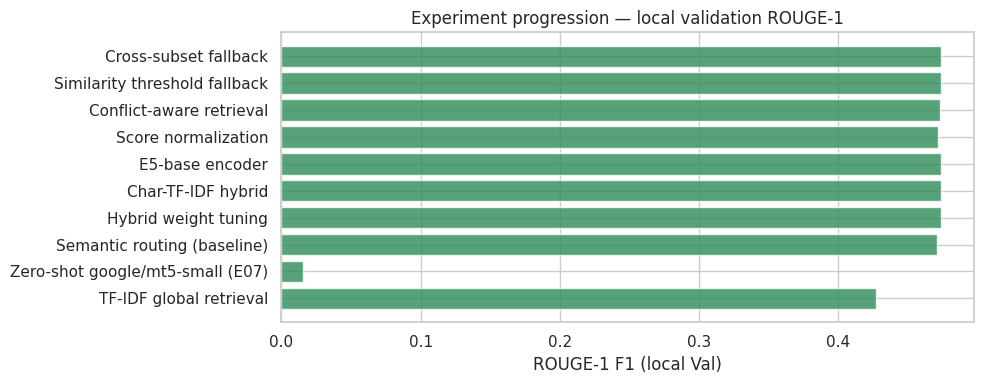

Saved: /content/multilingual-health-qa/figures/experiment_progression.png


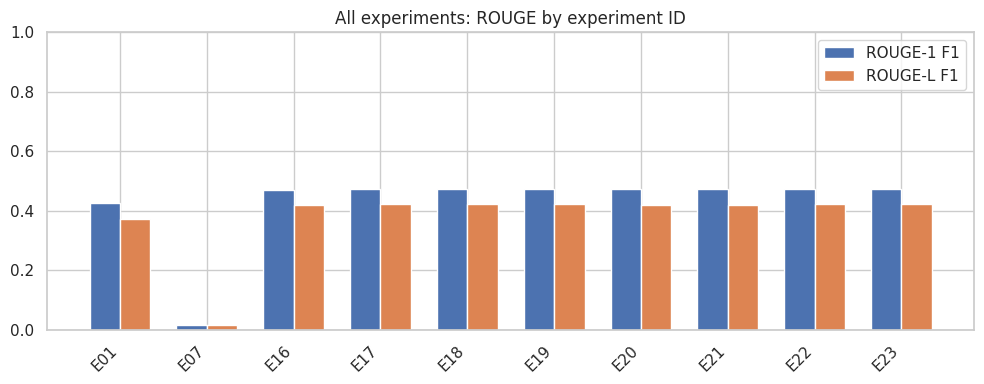

Saved: /content/multilingual-health-qa/figures/experiment_progression_bars.png


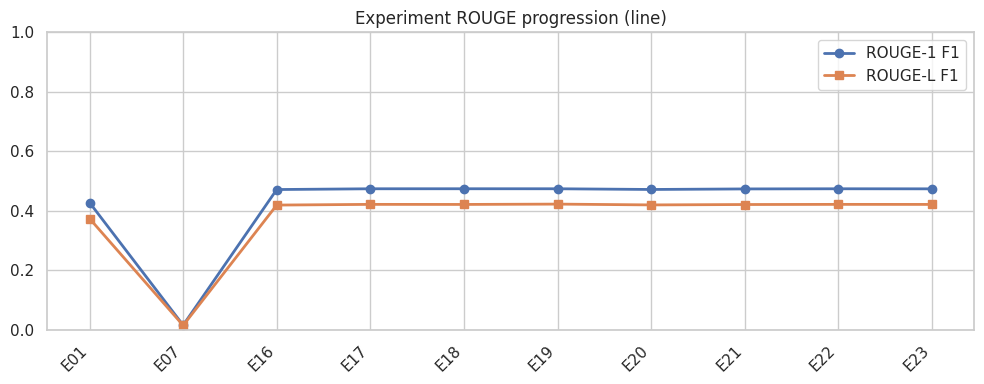

Saved: /content/multilingual-health-qa/figures/experiment_progression_line.png

Figures saved under: /content/multilingual-health-qa/figures
Experiment log: /content/multilingual-health-qa/experiment_log.json


In [ ]:
summary = tracker.to_dataframe()
print('Experiment log:')
display(summary)

if not summary.empty and summary['rouge1_f1'].notna().any():
    plot_df = summary.dropna(subset=['rouge1_f1'])

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(plot_df['name'], plot_df['rouge1_f1'], color='seagreen', alpha=0.8)
    ax.set_xlabel('ROUGE-1 F1 (local Val)')
    ax.set_title('Experiment progression — local validation ROUGE-1')
    exp_path = FIGURES_DIR / 'experiment_progression.png'
    plt.tight_layout()
    plt.savefig(exp_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {exp_path}')

    fig, ax = plt.subplots(figsize=(10, 4))
    x = np.arange(len(plot_df))
    w = 0.35
    ax.bar(x - w/2, plot_df['rouge1_f1'], w, label='ROUGE-1 F1')
    if plot_df['rougeL_f1'].notna().any():
        ax.bar(x + w/2, plot_df['rougeL_f1'], w, label='ROUGE-L F1')
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df['id'], rotation=45, ha='right')
    ax.set_ylim(0, 1)
    ax.set_title('All experiments: ROUGE by experiment ID')
    ax.legend()
    plt.tight_layout()
    exp_bar_path = FIGURES_DIR / 'experiment_progression_bars.png'
    plt.savefig(exp_bar_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {exp_bar_path}')

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(range(len(plot_df)), plot_df['rouge1_f1'], marker='o', label='ROUGE-1 F1', linewidth=2)
    if plot_df['rougeL_f1'].notna().any():
        ax.plot(range(len(plot_df)), plot_df['rougeL_f1'], marker='s', label='ROUGE-L F1', linewidth=2)
    ax.set_xticks(range(len(plot_df)))
    ax.set_xticklabels(plot_df['id'], rotation=45, ha='right')
    ax.set_ylim(0, 1)
    ax.set_title('Experiment ROUGE progression (line)')
    ax.legend()
    plt.tight_layout()
    exp_line_path = FIGURES_DIR / 'experiment_progression_line.png'
    plt.savefig(exp_line_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {exp_line_path}')

print(f'\nFigures saved under: {FIGURES_DIR}')
print(f'Experiment log: {EXPERIMENT_LOG_PATH}')


## 17 — Reproducibility notes

| Item | Value |
|---|---|
| Random seed | `SEED` (set in imports cell) |
| Validation metric | ROUGE-1 / ROUGE-L F1 via `rouge-score` |
| Primary encoder | `paraphrase-multilingual-mpnet-base-v2` |
| Experiment log | `WORK_DIR/experiment_log.json` |
| Figures | `WORK_DIR/figures/` |
| Leaderboard screenshot | `images/zindi-ranking.png` |
| Primary submission | `WORK_DIR/submission_semantic_routing.csv` (E16) |
| Ablation submissions | `WORK_DIR/submission_e17_*.csv` … `submission_e23_*.csv` |

Re-run Sections 2–8 after a runtime restart before retrieval or LLM experiments. Document the Colab runtime type (CPU / T4 GPU) and package versions when reporting results.